Raw data: 274 months (2003-01-01 -> 2025-11-01)
IMFs computed without lookahead: 4
NaNs in IMF_1: 25 (first 24 months discarded)
Available data: 249 months (2005-02-01 -> 2025-11-01)
=== LAG SELECTION BY WALK-FORWARD CV ===
  Lag |   Mean F1 CV
----------------------
    3  |       0.4504
    6  |       0.2356
    9  |       0.3868
   12  |       0.5022

-> Best lag by CV: 12 (F1_cv=0.5022)
=== WTI MONTHLY RETURN DISTRIBUTION ===
Total observations: 249

Basic statistics:
  Mean:  0.68%
  Std:   11.12%
  Min:   -54.24%
  Max:   88.38%

Percentiles (absolute value):
  P25: 3.29%
  P33: 4.45%
  P50: 6.27%
  P66: 8.30%
  P75: 9.58%
  P90: 13.97%

Distribution by magnitude (proposed thresholds):
  NEGLIGIBLE  :  38 obs (15.3%)
  SMALL       :  53 obs (21.3%)
  MEDIUM      :  99 obs (39.8%)
  LARGE       :  59 obs (23.7%)


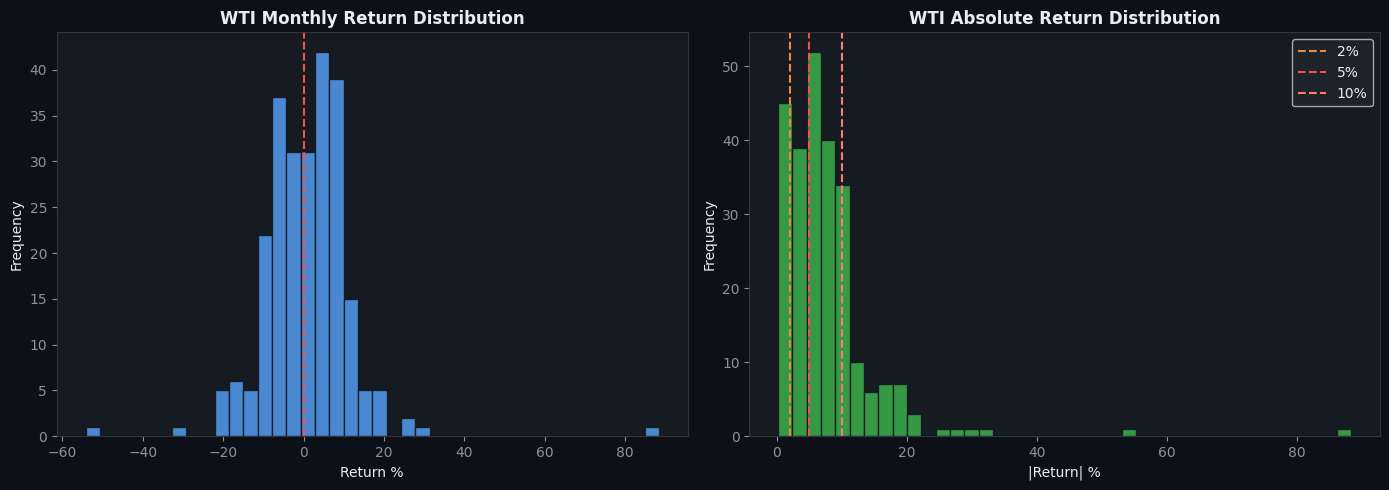


=== LAG CONFIGURATION COMPARISON ===
 Lags | Features |    Acc |     F1 |    AUC
------------------------------------------
Train — up: 105 | down: 84
Suggested scale_pos_weight: 0.80
    3  |       50 | 0.4667 | 0.5000 | 0.5467
    6  |       95 | 0.5667 | 0.5806 | 0.6444
    9  |      140 | 0.5667 | 0.6061 | 0.6000
   12  |      185 | 0.7333 | 0.7647 | 0.8267

-> Best configuration by F1: 12 lags (F1=0.7647)

=== STABILITY ANALYSIS (12 lags, multiple seeds) ===
Mean F1: 0.6968
F1 std:  0.0372
F1 min/max: 0.6207 / 0.7647

F1 on TRAIN: 0.7981
F1 on TEST:  0.7647

Target distribution in test:
  Months up:   15
  Months down: 15
  Longest same-direction streak: 4

=== MODEL BENCHMARK (12 lags) ===
Model           |    Acc |     F1 |    AUC
------------------------------------------
XGBoost         | 0.7333 | 0.7647 | 0.8267
LightGBM        | 0.6333 | 0.6452 | 0.6311
RandomForest    | 0.5667 | 0.6667 | 0.6489
ExtraTrees      | 0.4667 | 0.5556 | 0.5467
LogisticReg     | 0.4667 | 0.4286 | 

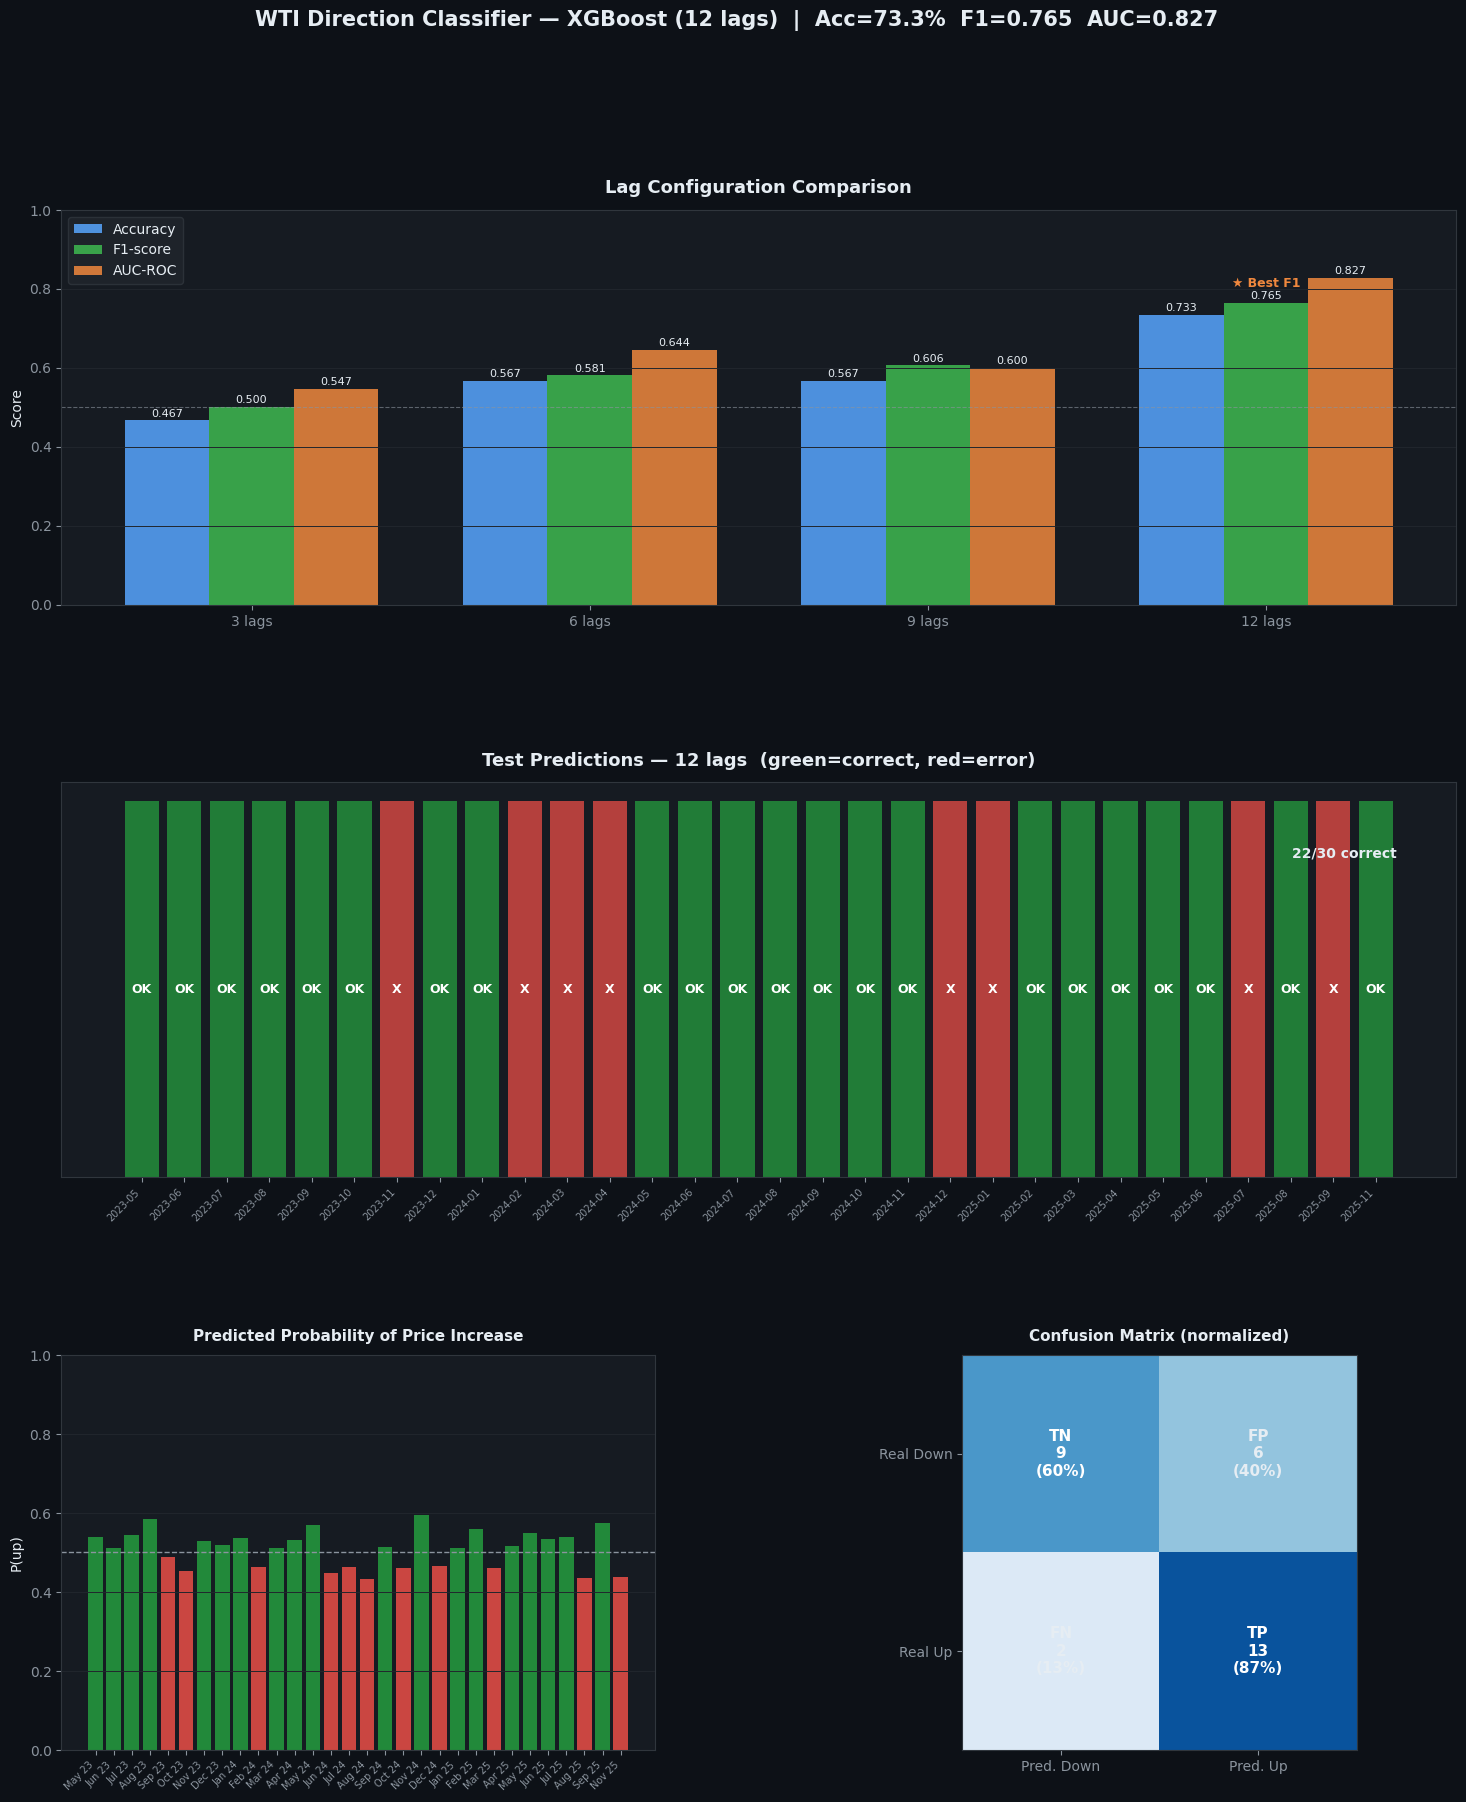


  STRATEGY SUMMARY — WTI (test period)
  Period: 2023-05 -> 2025-09  (29 months)
  Model correct predictions: 21/29
------------------------------------------------------------
Metric                   Buy&Hold    Buy-Only  Long/Short
------------------------------------------------------------
Total Return (%)           -14.0%       46.8%      134.7%
Sharpe Ratio                -0.14        1.03        1.77
Max Drawdown (%)           -35.9%      -13.2%      -13.2%
Final Capital ($)           8,599      14,683      23,465


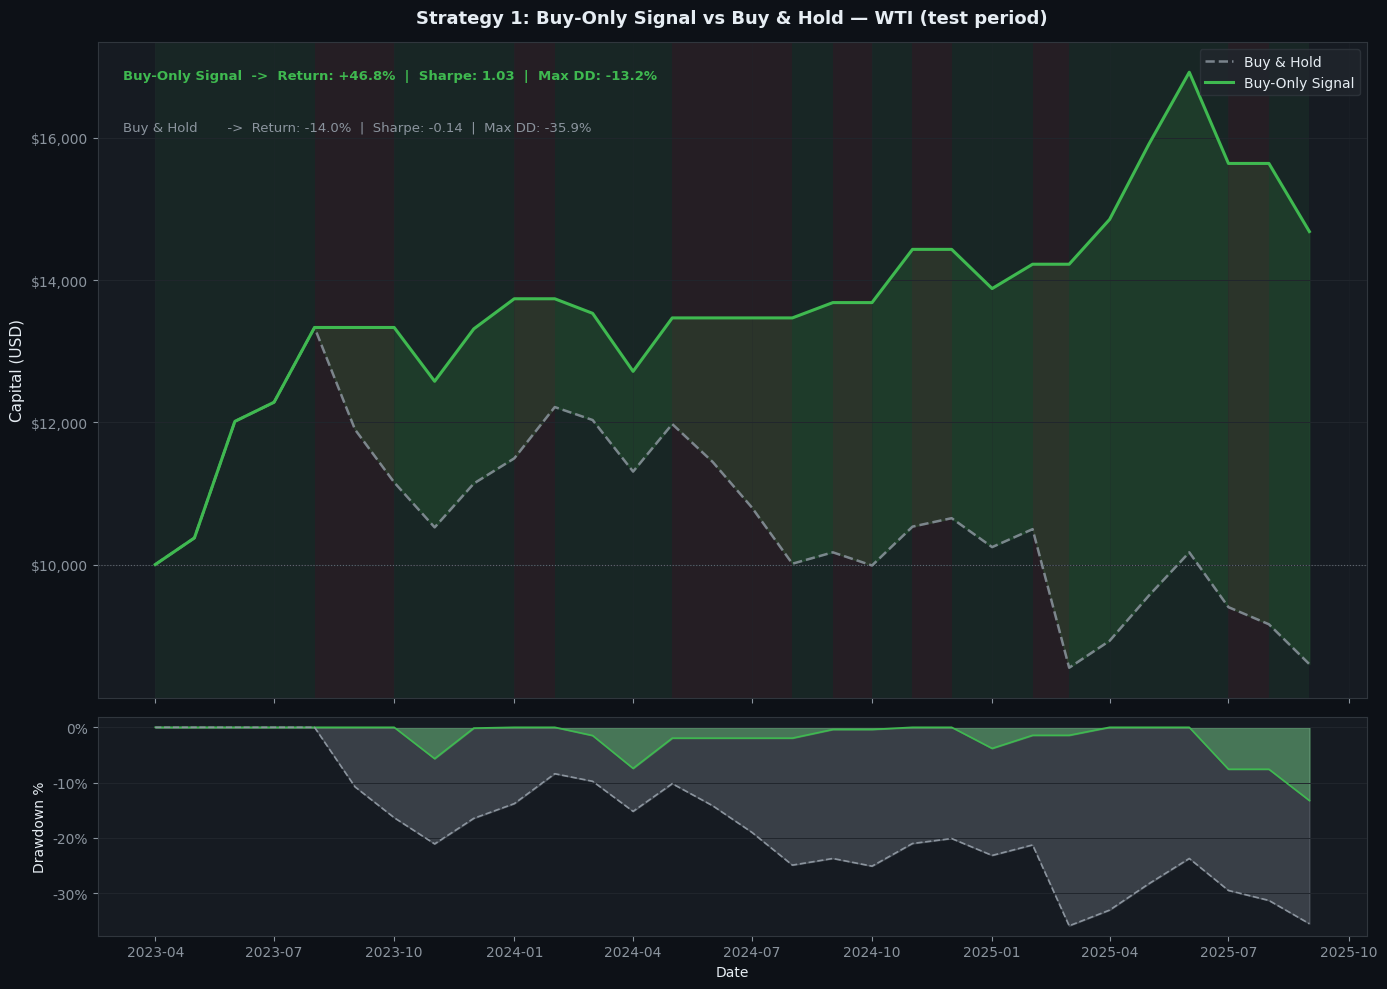

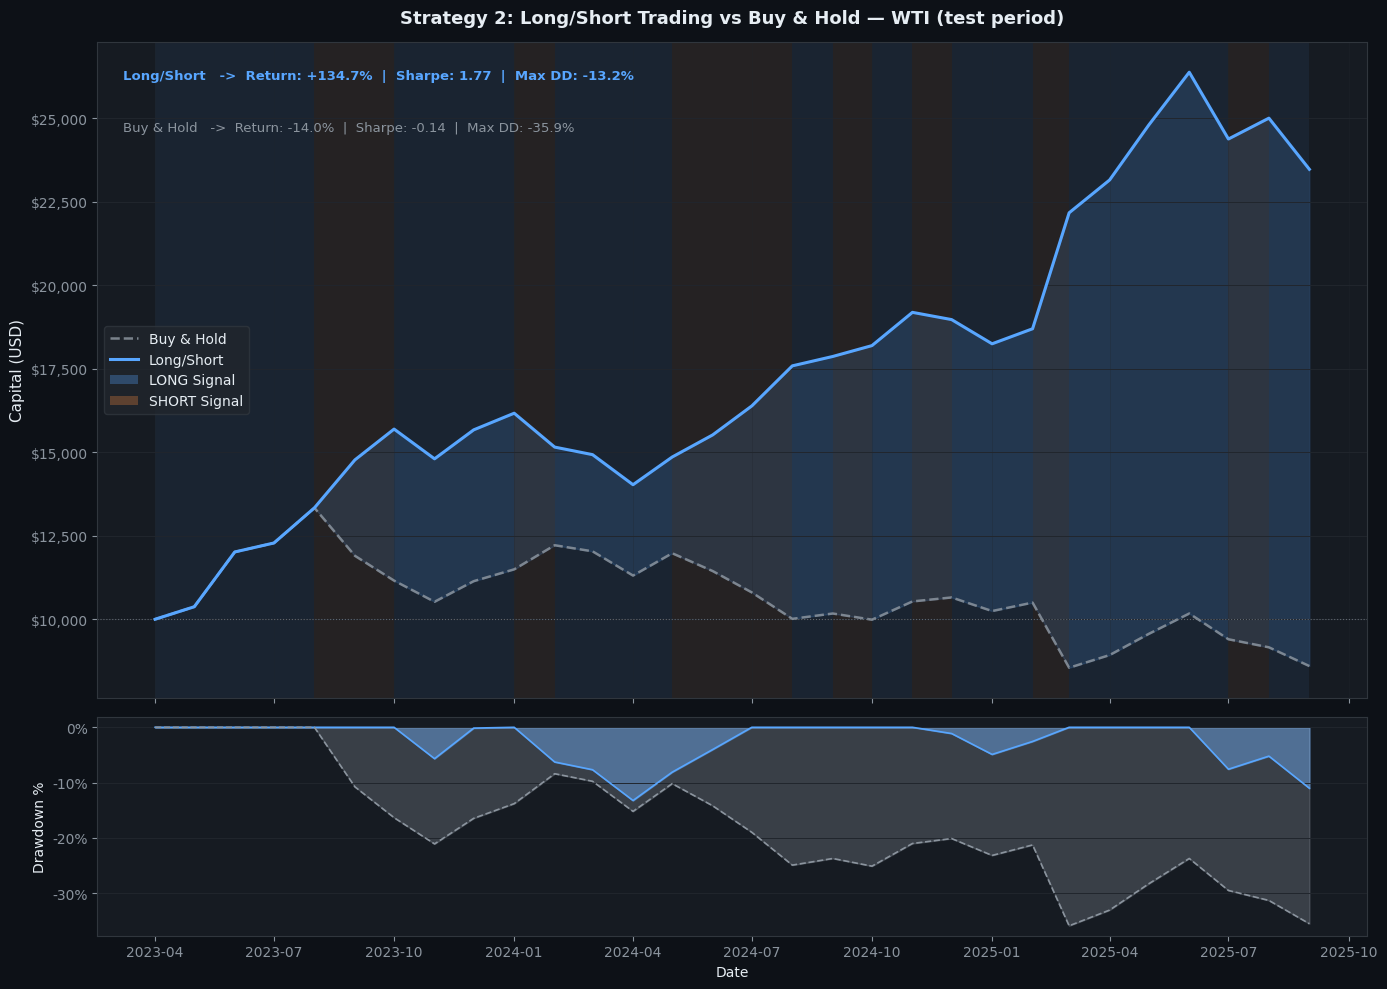


FINAL SUMMARY
Model: XGBoost
Start: 2003-01-01
Lags:  12
  Accuracy : 73.3%
  F1-score : 0.7647
  AUC-ROC  : 0.8267

Prediction for 2025-12:
  DOWN  (P=43.8% up / P=56.2% down)

=== ERRORS WITH NEXT MONTH RETURN ===
Date       |   Real |   Pred |  Next Month Change | Cause
----------------------------------------------------------------------
2023-11    |   DOWN |     UP |              -5.7%
2024-02    |     UP |   DOWN |               6.3%
2024-03    |   DOWN |     UP |              -1.5%
2024-04    |   DOWN |     UP |              -6.0%
2024-12    |     UP |   DOWN |               1.1%
2025-01    |   DOWN |     UP |              -3.8%
2025-07    |   DOWN |     UP |              -7.6%
2025-09    |   DOWN |     UP |              -6.1%


In [ ]:
# -*- coding: utf-8 -*-
"""Untitled4.ipynb

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/1OsFkb2WqTzf8tOfLHaFWpjbisSemCM8Z
"""

# -*- coding: utf-8 -*-
"""
WTI Direction Prediction — XGBoost
Target: Will WTI price go up (1) or down (0) next month?
Features: lagged financial variables + technical indicators + EMD
Configuration: START=2003, 12 lags, XGBoost
Result: F1=0.765, Acc=73.3%, F1 mean seeds=0.697, std=0.048
"""

# =========================
# 0. IMPORTS
# =========================
import subprocess
subprocess.run(["pip", "install", "EMD-signal", "-q"])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
import itertools
warnings.filterwarnings("ignore")

import yfinance as yf
from pandas_datareader import data as pdr
from PyEMD import EMD
from itertools import combinations

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                               VotingClassifier)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                              confusion_matrix, classification_report)
from sklearn.inspection import permutation_importance
from sklearn.model_selection import TimeSeriesSplit

SEED = 42
np.random.seed(SEED)

# =========================
# 1. GLOBAL PARAMETERS
# =========================
START       = "2003-01-01"
END         = "2026-03-31"
TEST_MONTHS = 30
VAL_MONTHS  = 18
LAG_OPTIONS = [3, 6, 9, 12]

# =========================
# 2. DATA DOWNLOAD
# =========================
def download_close(ticker, col_name, start, end):
    x = yf.download(ticker, start=start, end=end,
                    auto_adjust=False, progress=False)
    if isinstance(x.columns, pd.MultiIndex):
        if "Close" in x.columns.get_level_values(0):
            s = x["Close"].iloc[:, 0]
        elif "Close" in x.columns.get_level_values(1):
            s = x.xs("Close", axis=1, level=1).iloc[:, 0]
        else:
            raise ValueError(f"Could not find 'Close' for {ticker}")
    else:
        if "Close" not in x.columns:
            raise ValueError(f"Could not find 'Close' for {ticker}")
        s = x["Close"]
    s = pd.Series(s).copy()
    s.name = col_name
    return s.dropna()

print("Downloading market data...")
wti   = download_close("CL=F",     "WTI",   START, END)
sp500 = download_close("^GSPC",    "SP500", START, END)
dxy   = download_close("DX-Y.NYB", "DXY",   START, END)

print("Downloading FRED data...")
brent  = pdr.DataReader("DCOILBRENTEU", "fred", START, END)
vix    = pdr.DataReader("VIXCLS",       "fred", START, END)
cpi    = pdr.DataReader("CPIAUCSL",     "fred", START, END)
gepu   = pdr.DataReader("GEPUCURRENT",  "fred", START, END)
t10y   = pdr.DataReader("GS10",         "fred", START, END)
epu_us = pdr.DataReader("USEPUINDXM",   "fred", START, END)
tpu    = pdr.DataReader("EPUTrade",     "fred", START, END)
prod   = pdr.DataReader("IPG21112S",    "fred", START, END)

vix.columns    = ["VIX"]
cpi.columns    = ["CPI"]
gepu.columns   = ["GEPU"]
t10y.columns   = ["T10Y"]
epu_us.columns = ["EPU_US"]
tpu.columns    = ["TPU"]
brent.columns  = ["BRENT"]
prod.columns   = ["PROD"]

# Monthly resampling
wti   = wti.resample("M").last()
sp500 = sp500.resample("M").last()
dxy   = dxy.resample("M").last()
brent = brent.resample("M").last()
vix    = vix.resample("M").last()
cpi    = cpi.resample("M").last()
gepu   = gepu.resample("M").last()
t10y   = t10y.resample("M").last()
epu_us = epu_us.resample("M").last()
tpu    = tpu.resample("M").last()
prod   = prod.resample("M").last()

# Normalize indices to first day of each month
for obj in [wti, sp500, dxy, brent]:
    obj.index = obj.index.to_period("M").to_timestamp(how="start")
for obj in [vix, cpi, gepu, t10y, epu_us, tpu, prod]:
    obj.index = obj.index.to_period("M").to_timestamp(how="start")

df = pd.concat([wti, vix, cpi, sp500, dxy, brent, gepu, t10y, epu_us, tpu, prod], axis=1)
df = df.replace([np.inf, -np.inf], np.nan).dropna()

print(f"Raw data: {len(df)} months ({df.index[0].date()} -> {df.index[-1].date()})")

# =========================
# 3. FEATURE ENGINEERING
# =========================
df_feat = pd.DataFrame(index=df.index)

# Log returns — financial variables
df_feat["WTI_ret"]   = np.log(df["WTI"]).diff()
df_feat["VIX_ret"]   = np.log(df["VIX"]).diff()
df_feat["SP500_ret"] = np.log(df["SP500"]).diff()
df_feat["DXY_ret"]   = np.log(df["DXY"]).diff()
df_feat["BRENT_ret"] = np.log(df["BRENT"]).diff()

# Log differences — macroeconomic variables
df_feat["INF_logdiff"]    = np.log(df["CPI"]).diff()
df_feat["GEPU_logdiff"]   = np.log(df["GEPU"]).diff()
df_feat["EPU_US_logdiff"] = np.log(df["EPU_US"]).diff()
df_feat["TPU_logdiff"]    = np.log(df["TPU"]).diff()
df_feat["PROD_logdiff"]   = np.log(df["PROD"]).diff()

# First difference — interest rate
df_feat["T10Y_diff"] = df["T10Y"].diff()

# Technical indicators — no lookahead bias
ema12 = df["WTI"].ewm(span=12, adjust=False).mean()
ema24 = df["WTI"].ewm(span=24, adjust=False).mean()
df_feat["EMA_12"] = ema12 / df["WTI"] - 1
df_feat["EMA_24"] = ema24 / df["WTI"] - 1
df_feat["MACD"]   = (ema12 - ema24) / df["WTI"]

delta = df["WTI"].diff()
gain  = delta.clip(lower=0).ewm(span=6, adjust=False).mean()
loss  = (-delta.clip(upper=0)).ewm(span=6, adjust=False).mean()
rsi   = 100 - (100 / (1 + gain / (loss + 1e-10)))
df_feat["RSI_6"] = rsi / 100

bb_mid   = df["WTI"].rolling(12).mean()
bb_std   = df["WTI"].rolling(12).std()
bb_upper = bb_mid + 2 * bb_std
bb_lower = bb_mid - 2 * bb_std
df_feat["BB_pct"] = (df["WTI"] - bb_lower) / (bb_upper - bb_lower + 1e-10)

# EMD on WTI_ret — no lookahead bias (expanding window)
N_IMFS  = 4
MIN_OBS = 24

imf_data = {f"IMF_{i+1}": np.full(len(df_feat), np.nan) for i in range(N_IMFS)}

wti_ret_clean = df_feat["WTI_ret"].dropna()
indices       = wti_ret_clean.index
values        = wti_ret_clean.values

for t in range(MIN_OBS, len(values)):
    serie = values[:t+1]
    try:
        emd  = EMD()
        imfs = emd.emd(serie, max_imf=N_IMFS)
        for i in range(min(N_IMFS, imfs.shape[0])):
            pos = df_feat.index.get_loc(indices[t])
            imf_data[f"IMF_{i+1}"][pos] = imfs[i, -1]
    except Exception:
        pass

for i in range(N_IMFS):
    df_feat[f"IMF_{i+1}"] = imf_data[f"IMF_{i+1}"]

print(f"IMFs computed without lookahead: {N_IMFS}")
print(f"NaNs in IMF_1: {df_feat['IMF_1'].isna().sum()} "
      f"(first {MIN_OBS} months discarded)")

# Target variable
df_feat["target"] = (df_feat["WTI_ret"].shift(-1) > 0).astype(int)

df_feat = df_feat.replace([np.inf, -np.inf], np.nan).dropna()

print(f"Available data: {len(df_feat)} months "
      f"({df_feat.index[0].date()} -> {df_feat.index[-1].date()})")

# Variables to be lagged
LAG_VARS = [
    "WTI_ret", "VIX_ret", "SP500_ret", "DXY_ret", "BRENT_ret",
    "INF_logdiff", "GEPU_logdiff", "EPU_US_logdiff", "TPU_logdiff",
    "T10Y_diff", "PROD_logdiff",
    "IMF_1", "IMF_2", "IMF_3", "IMF_4"
]

# Technical indicators — used without lagging
TECH_VARS = ["RSI_6", "EMA_12", "EMA_24", "MACD", "BB_pct"]

# =========================
# 4. FEATURE MATRIX CONSTRUCTION
# =========================
def build_features(df_feat, max_lag):
    frames = []
    for var in LAG_VARS:
        for lag in range(1, max_lag + 1):
            col = df_feat[var].shift(lag)
            col.name = f"{var}_lag{lag}"
            frames.append(col)
    for var in TECH_VARS:
        frames.append(df_feat[var])
    X = pd.concat(frames, axis=1)
    y = df_feat["target"]
    combined = pd.concat([X, y], axis=1).dropna()
    return combined.drop("target", axis=1), combined["target"]

# =========================
# 5. TEMPORAL SPLIT
# =========================
n_test = TEST_MONTHS
n_val  = VAL_MONTHS

def get_splits(X, y):
    n    = len(X)
    n_tr = n - n_test - n_val
    return (X.iloc[:n_tr], y.iloc[:n_tr],
            X.iloc[n_tr:n_tr+n_val], y.iloc[n_tr:n_tr+n_val],
            X.iloc[n_tr+n_val:], y.iloc[n_tr+n_val:])

# =========================
# 5B. LAG SELECTION BY WALK-FORWARD CV
# =========================
def walk_forward_cv(df_feat, max_lag, n_splits=5):
    X, y = build_features(df_feat, max_lag)
    tscv = TimeSeriesSplit(n_splits=n_splits)

    f1_scores = []
    for train_idx, test_idx in tscv.split(X):
        X_tr = X.iloc[train_idx]
        y_tr = y.iloc[train_idx]
        X_te = X.iloc[test_idx]
        y_te = y.iloc[test_idx]

        if len(np.unique(y_te)) < 2:
            continue

        ratio_cv = (y_tr==0).sum() / y_tr.sum()

        m = XGBClassifier(
            n_estimators=50, max_depth=1, learning_rate=0.1,
            subsample=0.6, colsample_bytree=0.4,
            reg_alpha=2.0, reg_lambda=10.0,
            min_child_weight=10, gamma=2.0,
            scale_pos_weight=ratio_cv,
            random_state=SEED, verbosity=0
        )
        m.fit(X_tr, y_tr)
        f1_scores.append(f1_score(m.predict(X_te), y_te, zero_division=0))

    return np.mean(f1_scores) if f1_scores else 0.0

print("=== LAG SELECTION BY WALK-FORWARD CV ===")
print(f"{'Lag':>5} | {'Mean F1 CV':>12}")
print("-" * 22)

cv_results = {}
for max_lag in LAG_OPTIONS:
    f1_cv = walk_forward_cv(df_feat, max_lag)
    cv_results[max_lag] = f1_cv
    print(f"  {max_lag:>3}  | {f1_cv:>12.4f}")

best_lag_cv = max(cv_results, key=cv_results.get)
print(f"\n-> Best lag by CV: {best_lag_cv} "
      f"(F1_cv={cv_results[best_lag_cv]:.4f})")

# =========================
# WTI RETURN DISTRIBUTION ANALYSIS
# =========================
ret = df_feat["WTI_ret"].dropna()
pct_changes = (np.exp(ret) - 1) * 100
abs_changes = np.abs(pct_changes)

print("=== WTI MONTHLY RETURN DISTRIBUTION ===")
print(f"Total observations: {len(pct_changes)}")
print(f"\nBasic statistics:")
print(f"  Mean:  {pct_changes.mean():.2f}%")
print(f"  Std:   {pct_changes.std():.2f}%")
print(f"  Min:   {pct_changes.min():.2f}%")
print(f"  Max:   {pct_changes.max():.2f}%")

print(f"\nPercentiles (absolute value):")
for p in [25, 33, 50, 66, 75, 90]:
    print(f"  P{p:>2}: {np.percentile(abs_changes, p):.2f}%")

print(f"\nDistribution by magnitude (proposed thresholds):")
for label, lo, hi in [
    ("NEGLIGIBLE", 0,  2),
    ("SMALL",      2,  5),
    ("MEDIUM",     5, 10),
    ("LARGE",     10, 999)
]:
    n = ((abs_changes >= lo) & (abs_changes < hi)).sum()
    print(f"  {label:<12}: {n:>3} obs ({n/len(abs_changes):.1%})")

# Histogram
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor("white")

ax1 = axes[0]
ax1.set_facecolor("white")
ax1.hist(pct_changes, bins=40, color="#58a6ff", alpha=0.8, edgecolor="white")
ax1.axvline(0, color="#f85149", linewidth=1.5, linestyle="--")
ax1.set_title("WTI Monthly Return Distribution", color="white", fontweight="bold")
ax1.set_xlabel("Return %", color="white")
ax1.set_ylabel("Frequency", color="white")
ax1.tick_params(colors="#555555")
ax1.spines[["top","right","left","bottom"]].set_color("#30363d")

ax2 = axes[1]
ax2.set_facecolor("white")
ax2.hist(abs_changes, bins=40, color="#3fb950", alpha=0.8, edgecolor="white")
for threshold, color in [(2, "#f0883e"), (5, "#f85149"), (10, "#ff7b72")]:
    ax2.axvline(threshold, color=color, linewidth=1.5, linestyle="--",
                label=f"{threshold}%")
ax2.set_title("WTI Absolute Return Distribution", color="white", fontweight="bold")
ax2.set_xlabel("|Return| %", color="white")
ax2.set_ylabel("Frequency", color="white")
ax2.legend(facecolor="white", labelcolor="white")
ax2.tick_params(colors="#555555")
ax2.spines[["top","right","left","bottom"]].set_color("#30363d")

plt.tight_layout()
plt.show()

# =========================
# 6. LAG CONFIGURATION COMPARISON
# =========================
print("\n=== LAG CONFIGURATION COMPARISON ===")
print(f"{'Lags':>5} | {'Features':>8} | {'Acc':>6} | {'F1':>6} | {'AUC':>6}")
print("-" * 42)

X_tmp, y_tmp = build_features(df_feat, 12)
X_tr, y_tr, _, _, _, _ = get_splits(X_tmp, y_tmp)
ratio = (y_tr == 0).sum() / y_tr.sum()
print(f"Train — up: {y_tr.sum()} | down: {(y_tr==0).sum()}")
print(f"Suggested scale_pos_weight: {ratio:.2f}")

lag_results = {}
for max_lag in LAG_OPTIONS:
    X, y = build_features(df_feat, max_lag)
    X_train, y_train, X_val, y_val, X_test, y_test = get_splits(X, y)

    model = XGBClassifier(
        n_estimators=50, max_depth=1, learning_rate=0.1,
        subsample=0.6, colsample_bytree=0.4,
        reg_alpha=2.0, reg_lambda=10.0,
        min_child_weight=10, gamma=2.0,
        scale_pos_weight=ratio,
        random_state=SEED, verbosity=0
    )
    model.fit(X_train, y_train)

    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average="binary")
    auc = roc_auc_score(y_test, y_proba)

    lag_results[max_lag] = {
        "model": model, "X_test": X_test, "y_test": y_test,
        "y_pred": y_pred, "y_proba": y_proba,
        "acc": acc, "f1": f1, "auc": auc,
        "n_features": X.shape[1],
        "X_train": X_train, "y_train": y_train
    }
    print(f"  {max_lag:>3}  | {X.shape[1]:>8} | {acc:.4f} | {f1:.4f} | {auc:.4f}")

best_lag = best_lag_cv
print(f"\n-> Best configuration by F1: {best_lag} lags "
      f"(F1={lag_results[best_lag]['f1']:.4f})")

# Stability analysis with best_lag
print(f"\n=== STABILITY ANALYSIS ({best_lag} lags, multiple seeds) ===")
X, y = build_features(df_feat, best_lag)
X_train, y_train, X_val, y_val, X_test, y_test = get_splits(X, y)

f1_scores = []
for s in [0, 7, 13, 21, 42, 99, 123, 200, 314, 999]:
    m = XGBClassifier(
        n_estimators=50, max_depth=1, learning_rate=0.1,
        subsample=0.6, colsample_bytree=0.4,
        reg_alpha=2.0, reg_lambda=10.0,
        min_child_weight=10, gamma=2.0,
        scale_pos_weight=ratio, random_state=s, verbosity=0
    )
    m.fit(X_train, y_train)
    f1_scores.append(f1_score(m.predict(X_test), y_test))

print(f"Mean F1: {np.mean(f1_scores):.4f}")
print(f"F1 std:  {np.std(f1_scores):.4f}")
print(f"F1 min/max: {min(f1_scores):.4f} / {max(f1_scores):.4f}")

m_diag = XGBClassifier(
    n_estimators=50, max_depth=1, learning_rate=0.1,
    subsample=0.6, colsample_bytree=0.4,
    reg_alpha=2.0, reg_lambda=10.0,
    min_child_weight=10, gamma=2.0,
    scale_pos_weight=ratio, random_state=SEED, verbosity=0
)
m_diag.fit(X_train, y_train)
print(f"\nF1 on TRAIN: {f1_score(m_diag.predict(X_train), y_train):.4f}")
print(f"F1 on TEST:  {f1_score(m_diag.predict(X_test), y_test):.4f}")

print(f"\nTarget distribution in test:")
print(f"  Months up:   {y_test.sum()}")
print(f"  Months down: {(y_test==0).sum()}")
print(f"  Longest same-direction streak: "
      f"{max(len(list(g)) for _,g in itertools.groupby(y_test))}")

# =========================
# 6B. MODEL BENCHMARKING
# =========================
X, y = build_features(df_feat, best_lag)
X_train, y_train, X_val, y_val, X_test, y_test = get_splits(X, y)

models_benchmark = {
    "XGBoost": XGBClassifier(
        n_estimators=50, max_depth=1, learning_rate=0.1,
        subsample=0.6, colsample_bytree=0.4,
        reg_alpha=2.0, reg_lambda=10.0,
        min_child_weight=10, gamma=2.0,
        scale_pos_weight=ratio, random_state=SEED, verbosity=0
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=50, max_depth=1, learning_rate=0.1,
        subsample=0.6, colsample_bytree=0.4,
        reg_alpha=2.0, reg_lambda=10.0,
        min_child_samples=10, scale_pos_weight=ratio,
        random_state=SEED, verbose=-1
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=100, max_depth=3,
        min_samples_leaf=10, class_weight="balanced",
        random_state=SEED
    ),
    "ExtraTrees": ExtraTreesClassifier(
        n_estimators=100, max_depth=3,
        min_samples_leaf=10, class_weight="balanced",
        random_state=SEED
    ),
    "LogisticReg": LogisticRegression(
        C=0.1, class_weight="balanced",
        max_iter=1000, random_state=SEED
    ),
    "SVM_RBF": SVC(
        C=1.0, kernel="rbf", gamma="scale",
        class_weight="balanced", probability=True,
        random_state=SEED
    ),
    "LDA": LinearDiscriminantAnalysis(),
    "NaiveBayes": GaussianNB()
}

print(f"\n=== MODEL BENCHMARK ({best_lag} lags) ===")
print(f"{'Model':<15} | {'Acc':>6} | {'F1':>6} | {'AUC':>6}")
print("-" * 42)

benchmark_results = {}
for name, clf in models_benchmark.items():
    clf.fit(X_train, y_train)
    y_pred_b  = clf.predict(X_test)
    y_proba_b = clf.predict_proba(X_test)[:, 1]
    acc_b = accuracy_score(y_test, y_pred_b)
    f1_b  = f1_score(y_test, y_pred_b)
    auc_b = roc_auc_score(y_test, y_proba_b)
    benchmark_results[name] = {"acc": acc_b, "f1": f1_b, "auc": auc_b, "model": clf}
    print(f"{name:<15} | {acc_b:.4f} | {f1_b:.4f} | {auc_b:.4f}")

best_model_name = max(benchmark_results, key=lambda k: benchmark_results[k]["f1"])
print(f"\n-> Best model by F1: {best_model_name} "
      f"(F1={benchmark_results[best_model_name]['f1']:.4f})")

# Ensemble search
candidates = {
    "XGBoost":      models_benchmark["XGBoost"],
    "LightGBM":     models_benchmark["LightGBM"],
    "RandomForest": models_benchmark["RandomForest"],
    "NaiveBayes":   models_benchmark["NaiveBayes"],
    "LDA":          models_benchmark["LDA"]
}

print("\n=== ENSEMBLE SEARCH ===")
print(f"{'Combination':<35} | {'F1':>6} | {'AUC':>6}")
print("-" * 50)

best_ens_f1   = 0
best_ens_name = ""

for r in [2, 3]:
    for combo in combinations(candidates.keys(), r):
        ens = VotingClassifier(
            estimators=[(n, candidates[n]) for n in combo],
            voting="soft"
        )
        ens.fit(X_train, y_train)
        yp    = ens.predict(X_test)
        ypr   = ens.predict_proba(X_test)[:, 1]
        f1_e  = f1_score(y_test, yp)
        auc_e = roc_auc_score(y_test, ypr)
        name  = " + ".join(combo)
        print(f"{name:<35} | {f1_e:.4f} | {auc_e:.4f}")
        if f1_e > best_ens_f1:
            best_ens_f1   = f1_e
            best_ens_name = name

print(f"\n-> Best combination: {best_ens_name} (F1={best_ens_f1:.4f})")

# Ensemble stability — LightGBM + RF
print(f"\n=== ENSEMBLE STABILITY (LightGBM + RandomForest) ===")
f1_ens = []
for s in [0, 7, 13, 21, 42, 99, 123, 200, 314, 999]:
    ens_s = VotingClassifier(
        estimators=[
            ("lgbm", LGBMClassifier(
                n_estimators=50, max_depth=1, learning_rate=0.1,
                subsample=0.6, colsample_bytree=0.4,
                reg_alpha=2.0, reg_lambda=10.0,
                min_child_samples=10, scale_pos_weight=ratio,
                random_state=s, verbose=-1)),
            ("rf", RandomForestClassifier(
                n_estimators=100, max_depth=3,
                min_samples_leaf=10, class_weight="balanced",
                random_state=s))
        ],
        voting="soft"
    )
    ens_s.fit(X_train, y_train)
    f1_ens.append(f1_score(ens_s.predict(X_test), y_test))

print(f"Mean F1: {np.mean(f1_ens):.4f}")
print(f"F1 std:  {np.std(f1_ens):.4f}")
print(f"F1 min/max: {min(f1_ens):.4f} / {max(f1_ens):.4f}")

# =========================
# 7. FINAL MODEL — XGBOOST
# =========================
X, y = build_features(df_feat, best_lag)
X_train, y_train, X_val, y_val, X_test, y_test = get_splits(X, y)

best_model = XGBClassifier(
    n_estimators=50, max_depth=1, learning_rate=0.1,
    subsample=0.6, colsample_bytree=0.4,
    reg_alpha=2.0, reg_lambda=10.0,
    min_child_weight=10, gamma=2.0,
    scale_pos_weight=ratio,
    random_state=SEED, verbosity=0
)
best_model.fit(X_train, y_train)

y_pred  = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print(f"\n=== DETAILED REPORT — XGBoost ({best_lag} lags) ===")
print(classification_report(y_test, y_pred,
      target_names=["Down (0)", "Up (1)"]))

cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix:")
print(f"  TN={cm[0,0]}  FP={cm[0,1]}")
print(f"  FN={cm[1,0]}  TP={cm[1,1]}")

best = {
    "acc": accuracy_score(y_test, y_pred),
    "f1":  f1_score(y_test, y_pred),
    "auc": roc_auc_score(y_test, y_proba)
}

# Detailed predictions with probabilities
print("\n=== DETAILED TEST PREDICTIONS ===")
print(f"{'Date':<10} | {'Real':>6} | {'Pred':>6} | {'P(down)':>8} | "
      f"{'P(up)':>8} | {'Result':>10} | {'Confidence':>10}")
print("-" * 75)

for i, (date, real, pred, proba) in enumerate(zip(
        X_test.index, y_test.values, y_pred, y_proba)):
    real_str   = "UP"   if real == 1 else "DOWN"
    pred_str   = "UP"   if pred == 1 else "DOWN"
    result     = "OK"   if real == pred else "ERROR"
    p_down     = 1 - proba
    p_up       = proba
    confidence = max(p_down, p_up)
    conf_str   = f"{confidence:.1%} {'U' if p_up > p_down else 'D'}"
    print(f"{date.strftime('%Y-%m'):<10} | {real_str:>6} | {pred_str:>6} | "
          f"{p_down:>7.1%} | {p_up:>7.1%} | {result:>10} | {conf_str:>10}")

# Confidence level analysis
print("\n=== CONFIDENCE LEVEL ANALYSIS ===")
confidences = np.maximum(y_proba, 1 - y_proba)
thresholds  = [0.50, 0.53, 0.55, 0.58, 0.60]
print(f"{'Threshold':>10} | {'Predictions':>13} | {'Acc':>6} | {'F1':>6} | {'Coverage':>10}")
print("-" * 55)
for u in thresholds:
    mask = confidences >= u
    if mask.sum() == 0:
        continue
    acc_u = accuracy_score(y_test[mask], y_pred[mask])
    f1_u  = f1_score(y_test[mask], y_pred[mask], zero_division=0)
    cov   = mask.sum() / len(y_test)
    print(f"{u:>10.0%} | {mask.sum():>13} | {acc_u:.4f} | {f1_u:.4f} | {cov:>9.1%}")

# Error analysis by movement magnitude
print("\n=== MOVEMENT MAGNITUDE — ERRORS VS CORRECT PREDICTIONS ===")
print(f"{'Date':<10} | {'Real':>6} | {'Pred':>6} | {'Result':>10} | "
      f"{'WTI_ret':>8} | {'Change %':>9} | {'Magnitude':>10}")
print("-" * 80)

for date, real, pred, proba in zip(X_test.index, y_test.values, y_pred, y_proba):
    if date not in df_feat.index:
        continue
    wti_ret    = df_feat.loc[date, "WTI_ret"]
    change_pct = (np.exp(wti_ret) - 1) * 100
    real_str   = "UP"    if real == 1 else "DOWN"
    pred_str   = "UP"    if pred == 1 else "DOWN"
    result     = "ERROR" if real != pred else "OK"
    magnitude  = "LARGE"  if abs(change_pct) >= 5 else \
                 "MEDIUM" if abs(change_pct) >= 2 else "SMALL"
    print(f"{date.strftime('%Y-%m'):<10} | {real_str:>6} | {pred_str:>6} | "
          f"{result:>10} | {wti_ret:>8.4f} | {change_pct:>8.1f}% | {magnitude:>10}")

errors_mask  = y_test.values != y_pred
correct_mask = ~errors_mask
wti_rets_test = np.array([df_feat.loc[d, "WTI_ret"]
                           for d in X_test.index if d in df_feat.index])
changes_pct   = (np.exp(wti_rets_test) - 1) * 100

print(f"\n{'':->50}")
print(f"Mean absolute change on ERRORS:   "
      f"{np.mean(np.abs(changes_pct[errors_mask])):.2f}%")
print(f"Mean absolute change on CORRECT:  "
      f"{np.mean(np.abs(changes_pct[correct_mask])):.2f}%")
print(f"\nErrors with change < 2%: "
      f"{(np.abs(changes_pct[errors_mask]) < 2).sum()} out of {errors_mask.sum()}")
print(f"Errors with change > 5%: "
      f"{(np.abs(changes_pct[errors_mask]) > 5).sum()} out of {errors_mask.sum()}")

# =========================
# 8. NEXT MONTH PREDICTION
# =========================
X_all, y_all = build_features(df_feat, best_lag)
last_features = X_all.iloc[[-1]]
next_pred     = best_model.predict(last_features)[0]
next_proba    = best_model.predict_proba(last_features)[0]
last_date     = X_all.index[-1]
next_month    = last_date + pd.offsets.MonthBegin(1)

print(f"\n=== NEXT MONTH PREDICTION ===")
print(f"Last month with data: {last_date.strftime('%Y-%m')}")
print(f"Prediction for:       {next_month.strftime('%Y-%m')}")
print(f"Predicted direction:  {'UP' if next_pred == 1 else 'DOWN'}")
print(f"Probability up:       {next_proba[1]:.1%}")
print(f"Probability down:     {next_proba[0]:.1%}")

# =========================
# 9. VISUALIZATIONS
# =========================
fig = plt.figure(figsize=(18, 20))
fig.patch.set_facecolor("white")
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

COLOR_UP   = "#26a641"
COLOR_DOWN = "#f85149"
COLOR_GRID = "white"
COLOR_TEXT = "white"
COLOR_MUT  = "#555555"

plt.rcParams.update({
    "text.color": COLOR_TEXT,
    "axes.labelcolor": COLOR_TEXT,
    "xtick.color": COLOR_MUT,
    "ytick.color": COLOR_MUT,
})

# Panel 1: Lag comparison
ax1 = fig.add_subplot(gs[0, :])
ax1.set_facecolor("white")
lags_list = list(lag_results.keys())
accs = [lag_results[l]["acc"] for l in lags_list]
f1s  = [lag_results[l]["f1"]  for l in lags_list]
aucs = [lag_results[l]["auc"] for l in lags_list]

x = np.arange(len(lags_list))
w = 0.25
bars1 = ax1.bar(x - w, accs, w, label="Accuracy", color="#58a6ff", alpha=0.85)
bars2 = ax1.bar(x,     f1s,  w, label="F1-score", color="#3fb950", alpha=0.85)
bars3 = ax1.bar(x + w, aucs, w, label="AUC-ROC",  color="#f0883e", alpha=0.85)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        h = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2, h + 0.005,
                 f"{h:.3f}", ha="center", va="bottom",
                 fontsize=8, color=COLOR_TEXT)

ax1.set_xticks(x)
ax1.set_xticklabels([f"{l} lags" for l in lags_list])
ax1.set_ylim(0, 1.0)
ax1.axhline(0.5, color=COLOR_MUT, linestyle="--", linewidth=0.8, alpha=0.6)
ax1.set_title("Lag Configuration Comparison", color=COLOR_TEXT,
              fontsize=13, fontweight="bold", pad=12)
ax1.set_ylabel("Score", color=COLOR_TEXT)
ax1.legend(facecolor="white", edgecolor="#30363d", labelcolor=COLOR_TEXT)
ax1.grid(axis="y", color=COLOR_GRID, linewidth=0.7)
ax1.spines[["top","right","left","bottom"]].set_color("#30363d")

best_x = lags_list.index(best_lag)
ax1.annotate("★ Best F1", xy=(best_x, f1s[best_x] + 0.04),
             ha="center", color="#f0883e", fontsize=9, fontweight="bold")

# Panel 2: Predicted vs Real
ax2 = fig.add_subplot(gs[1, :])
ax2.set_facecolor("white")
test_dates = X_test.index
real_vals  = y_test.values
pred_vals  = y_pred

for i, (date, real, pred) in enumerate(zip(test_dates, real_vals, pred_vals)):
    correct = real == pred
    color   = COLOR_UP if correct else COLOR_DOWN
    ax2.bar(i, 1, color=color, alpha=0.7, width=0.8)
    ax2.text(i, 0.5, "OK" if correct else "X",
             ha="center", va="center", fontsize=9,
             color="white", fontweight="bold")

ax2.set_xticks(range(len(test_dates)))
ax2.set_xticklabels([d.strftime("%Y-%m") for d in test_dates],
                     rotation=45, ha="right", fontsize=7)
ax2.set_yticks([])
ax2.set_title(f"Test Predictions — {best_lag} lags  "
              f"(green=correct, red=error)", color=COLOR_TEXT,
              fontsize=13, fontweight="bold", pad=12)
ax2.spines[["top","right","left","bottom"]].set_color("#30363d")
n_correct = int((real_vals == pred_vals).sum())
ax2.text(len(test_dates) - 0.5, 0.85,
         f"{n_correct}/{len(real_vals)} correct",
         ha="right", color=COLOR_TEXT, fontsize=10, fontweight="bold")

# Panel 3: Probabilities
ax3 = fig.add_subplot(gs[2, 0])
ax3.set_facecolor("white")
colors_prob = [COLOR_UP if p >= 0.5 else COLOR_DOWN for p in y_proba]
ax3.bar(range(len(y_proba)), y_proba, color=colors_prob, alpha=0.8, width=0.8)
ax3.axhline(0.5, color=COLOR_MUT, linestyle="--", linewidth=1)
ax3.set_xticks(range(len(test_dates)))
ax3.set_xticklabels([d.strftime("%b %y") for d in test_dates],
                     rotation=45, ha="right", fontsize=7)
ax3.set_ylim(0, 1)
ax3.set_ylabel("P(up)", color=COLOR_TEXT)
ax3.set_title("Predicted Probability of Price Increase", color=COLOR_TEXT,
              fontsize=11, fontweight="bold", pad=10)
ax3.grid(axis="y", color=COLOR_GRID, linewidth=0.7)
ax3.spines[["top","right","left","bottom"]].set_color("#30363d")

# Panel 4: Confusion matrix
ax4 = fig.add_subplot(gs[2, 1])
ax4.set_facecolor("white")
cm_norm = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis]
ax4.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
labels = [["TN", "FP"], ["FN", "TP"]]
for i in range(2):
    for j in range(2):
        ax4.text(j, i, f"{labels[i][j]}\n{cm[i,j]}\n({cm_norm[i,j]:.0%})",
                 ha="center", va="center", fontsize=11,
                 color="white" if cm_norm[i,j] > 0.5 else COLOR_TEXT,
                 fontweight="bold")
ax4.set_xticks([0, 1])
ax4.set_yticks([0, 1])
ax4.set_xticklabels(["Pred. Down", "Pred. Up"])
ax4.set_yticklabels(["Real Down", "Real Up"])
ax4.set_title("Confusion Matrix (normalized)", color=COLOR_TEXT,
              fontsize=11, fontweight="bold", pad=10)
ax4.spines[["top","right","left","bottom"]].set_color("#30363d")

fig.suptitle(
    f"WTI Direction Classifier — XGBoost ({best_lag} lags)  |  "
    f"Acc={best['acc']:.1%}  F1={best['f1']:.3f}  AUC={best['auc']:.3f}",
    color=COLOR_TEXT, fontsize=15, fontweight="bold", y=0.98
)
plt.tight_layout()
plt.show()

# =========================
# 10. TRADING STRATEGY SIMULATION
# =========================
INITIAL_CAPITAL = 10_000  # USD

# WTI prices aligned to 30 test months
wti_test = df["WTI"].reindex(X_test.index).ffill()

# Real monthly returns (t to t+1)
real_returns = wti_test.pct_change().shift(-1).reindex(X_test.index)

# Remove last month (no future return available — 29 periods remain)
mask    = real_returns.notna()
mask_np = mask.values
dates   = X_test.index[mask]
ret     = real_returns[mask].values
pred_s  = y_pred[mask_np]

n = len(ret)  # 29 periods with valid return

# Performance metrics function
def compute_metrics(capital_curve):
    returns   = np.diff(capital_curve) / capital_curve[:-1]
    total_ret = (capital_curve[-1] / capital_curve[0] - 1) * 100
    sharpe    = (returns.mean() / (returns.std() + 1e-10)) * np.sqrt(12)
    peak      = np.maximum.accumulate(capital_curve)
    drawdown  = (capital_curve - peak) / peak
    max_dd    = drawdown.min() * 100
    return {
        "total_ret": total_ret,
        "sharpe":    sharpe,
        "max_dd":    max_dd,
        "drawdown":  drawdown
    }

# Strategy 0: Buy & Hold
capital_bh = [INITIAL_CAPITAL]
for r in ret:
    capital_bh.append(capital_bh[-1] * (1 + r))
capital_bh = np.array(capital_bh)
met_bh = compute_metrics(capital_bh)

# Strategy 1: Buy-Only Signal
# pred=1 -> buy (capture return) | pred=0 -> cash (return = 0)
capital_bo = [INITIAL_CAPITAL]
for r, p in zip(ret, pred_s):
    capital_bo.append(capital_bo[-1] * (1 + r) if p == 1 else capital_bo[-1])
capital_bo = np.array(capital_bo)
met_bo = compute_metrics(capital_bo)

# Strategy 2: Long/Short Trading
# pred=1 -> long (+return) | pred=0 -> short (-return)
capital_ls = [INITIAL_CAPITAL]
for r, p in zip(ret, pred_s):
    capital_ls.append(capital_ls[-1] * (1 + r) if p == 1 else capital_ls[-1] * (1 - r))
capital_ls = np.array(capital_ls)
met_ls = compute_metrics(capital_ls)

# Date axis (n+1 points)
start_date  = dates[0] - pd.DateOffset(months=1)
dates_plot  = pd.DatetimeIndex([start_date] + list(dates))

assert len(dates_plot) == len(capital_bh), \
    f"Misalignment: dates_plot={len(dates_plot)} vs capital={len(capital_bh)}"

# Console summary
print("\n" + "="*60)
print("  STRATEGY SUMMARY — WTI (test period)")
print("="*60)
print(f"  Period: {dates[0].strftime('%Y-%m')} -> {dates[-1].strftime('%Y-%m')}  ({n} months)")
print(f"  Model correct predictions: {int((y_test.values[mask_np] == pred_s).sum())}/{n}")
print("-"*60)
print(f"{'Metric':<22} {'Buy&Hold':>10} {'Buy-Only':>11} {'Long/Short':>11}")
print("-"*60)
print(f"{'Total Return (%)':<22} {met_bh['total_ret']:>9.1f}% "
      f"{met_bo['total_ret']:>10.1f}% {met_ls['total_ret']:>10.1f}%")
print(f"{'Sharpe Ratio':<22} {met_bh['sharpe']:>10.2f} "
      f"{met_bo['sharpe']:>11.2f} {met_ls['sharpe']:>11.2f}")
print(f"{'Max Drawdown (%)':<22} {met_bh['max_dd']:>9.1f}% "
      f"{met_bo['max_dd']:>10.1f}% {met_ls['max_dd']:>10.1f}%")
print(f"{'Final Capital ($)':<22} {capital_bh[-1]:>10,.0f} "
      f"{capital_bo[-1]:>11,.0f} {capital_ls[-1]:>11,.0f}")
print("="*60)

# Color palette
COLOR_BG    = "white"
COLOR_AX    = "white"
COLOR_GRID  = "white"
COLOR_TEXT  = "white"
COLOR_MUT   = "#555555"
COLOR_GREEN = "#3fb950"
COLOR_GRAY  = "#555555"
COLOR_BLUE  = "#58a6ff"
COLOR_RED   = "#f85149"
COLOR_AMBER = "#f0883e"

plt.rcParams.update({
    "text.color":       COLOR_TEXT,
    "axes.labelcolor":  COLOR_TEXT,
    "xtick.color":      COLOR_MUT,
    "ytick.color":      COLOR_MUT,
    "figure.facecolor": COLOR_BG,
    "axes.facecolor":   COLOR_AX,
})

# Chart 1: Buy-Only vs Buy & Hold
fig1, axes1 = plt.subplots(2, 1, figsize=(14, 10),
                            gridspec_kw={"height_ratios": [3, 1]},
                            facecolor=COLOR_BG)
fig1.subplots_adjust(hspace=0.08)

ax = axes1[0]
ax.set_facecolor(COLOR_AX)
ax.plot(dates_plot, capital_bh, color=COLOR_GRAY, linewidth=1.8,
        linestyle="--", label="Buy & Hold", alpha=0.85)
ax.plot(dates_plot, capital_bo, color=COLOR_GREEN, linewidth=2.2,
        label="Buy-Only Signal", zorder=3)

ax.fill_between(dates_plot, capital_bo, capital_bh,
                where=(capital_bo >= capital_bh),
                alpha=0.15, color=COLOR_GREEN)
ax.fill_between(dates_plot, capital_bo, capital_bh,
                where=(capital_bo < capital_bh),
                alpha=0.15, color=COLOR_RED)

for i in range(n):
    color = COLOR_GREEN if pred_s[i] == 1 else COLOR_RED
    ax.axvspan(dates_plot[i], dates_plot[i + 1],
               alpha=0.07, color=color, linewidth=0)

ax.axhline(INITIAL_CAPITAL, color=COLOR_MUT, linewidth=0.8,
           linestyle=":", alpha=0.6)

ax.text(0.02, 0.96,
        f"Buy-Only Signal  ->  Return: {met_bo['total_ret']:+.1f}%  |  "
        f"Sharpe: {met_bo['sharpe']:.2f}  |  Max DD: {met_bo['max_dd']:.1f}%",
        transform=ax.transAxes, fontsize=9.5, color=COLOR_GREEN,
        va="top", fontweight="bold")
ax.text(0.02, 0.88,
        f"Buy & Hold       ->  Return: {met_bh['total_ret']:+.1f}%  |  "
        f"Sharpe: {met_bh['sharpe']:.2f}  |  Max DD: {met_bh['max_dd']:.1f}%",
        transform=ax.transAxes, fontsize=9.5, color=COLOR_GRAY, va="top")

ax.set_ylabel("Capital (USD)", color=COLOR_TEXT, fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.legend(facecolor="white", edgecolor="#cccccc",
          labelcolor=COLOR_TEXT, fontsize=10)
ax.grid(axis="y", color=COLOR_GRID, linewidth=0.7)
ax.grid(axis="x", color=COLOR_GRID, linewidth=0.4, alpha=0.5)
ax.spines[["top","right","left","bottom"]].set_color("#cccccc")
ax.set_xticklabels([])
ax.set_title("Strategy 1: Buy-Only Signal vs Buy & Hold — WTI (test period)",
             color=COLOR_TEXT, fontsize=13, fontweight="bold", pad=14)

ax_dd = axes1[1]
ax_dd.set_facecolor(COLOR_AX)
ax_dd.fill_between(dates_plot, met_bo["drawdown"] * 100,
                   color=COLOR_GREEN, alpha=0.5)
ax_dd.fill_between(dates_plot, met_bh["drawdown"] * 100,
                   color=COLOR_GRAY, alpha=0.3)
ax_dd.plot(dates_plot, met_bo["drawdown"] * 100,
           color=COLOR_GREEN, linewidth=1.2)
ax_dd.plot(dates_plot, met_bh["drawdown"] * 100,
           color=COLOR_GRAY, linewidth=1.2, linestyle="--")
ax_dd.set_ylabel("Drawdown %", color=COLOR_TEXT, fontsize=10)
ax_dd.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax_dd.grid(axis="y", color=COLOR_GRID, linewidth=0.7)
ax_dd.spines[["top","right","left","bottom"]].set_color("#cccccc")
ax_dd.set_xlabel("Date", color=COLOR_TEXT, fontsize=10)

plt.tight_layout()
plt.show()

# Chart 2: Long/Short vs Buy & Hold
from matplotlib.patches import Patch

fig2, axes2 = plt.subplots(2, 1, figsize=(14, 10),
                            gridspec_kw={"height_ratios": [3, 1]},
                            facecolor=COLOR_BG)
fig2.subplots_adjust(hspace=0.08)

ax2 = axes2[0]
ax2.set_facecolor(COLOR_AX)
ax2.plot(dates_plot, capital_bh, color=COLOR_GRAY, linewidth=1.8,
         linestyle="--", label="Buy & Hold", alpha=0.85)
ax2.plot(dates_plot, capital_ls, color=COLOR_BLUE, linewidth=2.2,
         label="Long/Short", zorder=3)

ax2.fill_between(dates_plot, capital_ls, capital_bh,
                 where=(capital_ls >= capital_bh),
                 alpha=0.15, color=COLOR_BLUE)
ax2.fill_between(dates_plot, capital_ls, capital_bh,
                 where=(capital_ls < capital_bh),
                 alpha=0.15, color=COLOR_RED)

for i in range(n):
    color = COLOR_BLUE if pred_s[i] == 1 else COLOR_AMBER
    ax2.axvspan(dates_plot[i], dates_plot[i + 1],
                alpha=0.07, color=color, linewidth=0)

ax2.axhline(INITIAL_CAPITAL, color=COLOR_MUT, linewidth=0.8,
            linestyle=":", alpha=0.6)

ax2.text(0.02, 0.96,
         f"Long/Short   ->  Return: {met_ls['total_ret']:+.1f}%  |  "
         f"Sharpe: {met_ls['sharpe']:.2f}  |  Max DD: {met_ls['max_dd']:.1f}%",
         transform=ax2.transAxes, fontsize=9.5, color=COLOR_BLUE,
         va="top", fontweight="bold")
ax2.text(0.02, 0.88,
         f"Buy & Hold   ->  Return: {met_bh['total_ret']:+.1f}%  |  "
         f"Sharpe: {met_bh['sharpe']:.2f}  |  Max DD: {met_bh['max_dd']:.1f}%",
         transform=ax2.transAxes, fontsize=9.5, color=COLOR_GRAY, va="top")

legend_extra = [
    Patch(facecolor=COLOR_BLUE,  alpha=0.3, label="LONG Signal"),
    Patch(facecolor=COLOR_AMBER, alpha=0.3, label="SHORT Signal"),
]
ax2.set_ylabel("Capital (USD)", color=COLOR_TEXT, fontsize=11)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
handles, labels_ = ax2.get_legend_handles_labels()
ax2.legend(handles=handles + legend_extra,
           facecolor="white", edgecolor="#30363d",
           labelcolor=COLOR_TEXT, fontsize=10)
ax2.grid(axis="y", color=COLOR_GRID, linewidth=0.7)
ax2.grid(axis="x", color=COLOR_GRID, linewidth=0.4, alpha=0.5)
ax2.spines[["top","right","left","bottom"]].set_color("#30363d")
ax2.set_xticklabels([])
ax2.set_title("Strategy 2: Long/Short Trading vs Buy & Hold — WTI (test period)",
              color=COLOR_TEXT, fontsize=13, fontweight="bold", pad=14)

ax_dd2 = axes2[1]
ax_dd2.set_facecolor(COLOR_AX)
ax_dd2.fill_between(dates_plot, met_ls["drawdown"] * 100,
                    color=COLOR_BLUE, alpha=0.5)
ax_dd2.fill_between(dates_plot, met_bh["drawdown"] * 100,
                    color=COLOR_GRAY, alpha=0.3)
ax_dd2.plot(dates_plot, met_ls["drawdown"] * 100,
            color=COLOR_BLUE, linewidth=1.2)
ax_dd2.plot(dates_plot, met_bh["drawdown"] * 100,
            color=COLOR_GRAY, linewidth=1.2, linestyle="--")
ax_dd2.set_ylabel("Drawdown %", color=COLOR_TEXT, fontsize=10)
ax_dd2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax_dd2.grid(axis="y", color=COLOR_GRID, linewidth=0.7)
ax_dd2.spines[["top","right","left","bottom"]].set_color("#30363d")
ax_dd2.set_xlabel("Date", color=COLOR_TEXT, fontsize=10)

plt.tight_layout()
plt.show()

# =========================
# 11. FINAL SUMMARY
# =========================
print("\n" + "="*50)
print("FINAL SUMMARY")
print("="*50)
print(f"Model: XGBoost")
print(f"Start: {START}")
print(f"Lags:  {best_lag}")
print(f"  Accuracy : {best['acc']:.1%}")
print(f"  F1-score : {best['f1']:.4f}")
print(f"  AUC-ROC  : {best['auc']:.4f}")
print(f"\nPrediction for {next_month.strftime('%Y-%m')}:")
print(f"  {'UP' if next_pred == 1 else 'DOWN'}  "
      f"(P={next_proba[1]:.1%} up / P={next_proba[0]:.1%} down)")
print("="*50)

# =========================
# ERRORS WITH NEXT MONTH RETURN
# =========================
print("\n=== ERRORS WITH NEXT MONTH RETURN ===")
print(f"{'Date':<10} | {'Real':>6} | {'Pred':>6} | {'Next Month Change':>18} | {'Cause'}")
print("-" * 70)

for i, (date, real, pred) in enumerate(zip(X_test.index, y_test.values, y_pred)):
    if real != pred:
        # Next month index
        iloc_pos = list(df_feat.index).index(date)
        if iloc_pos + 1 < len(df_feat):
            next_ret = df_feat["WTI_ret"].iloc[iloc_pos + 1]
            next_pct = (np.exp(next_ret) - 1) * 100
        else:
            next_pct = float('nan')
        real_str = "UP"   if real == 1 else "DOWN"
        pred_str = "UP"   if pred == 1 else "DOWN"
        print(f"{date.strftime('%Y-%m'):<10} | {real_str:>6} | {pred_str:>6} | {next_pct:>17.1f}%")

In [ ]:
import pandas as pd

url = "https://www.matteoiacoviello.com/ai_gpr_files/ai_gpr_data_daily.csv"
ai_gpr = pd.read_csv(url, parse_dates=["Date"])
print(f"Última fecha: {ai_gpr['Date'].max().date()}")
print(ai_gpr.tail(5))

Última fecha: 2026-04-30
            Date  GPR_AI  GPR_AER  GPR_OIL  GPR_NONOIL
24222 2026-04-26  142.38   179.07   621.43      111.05
24223 2026-04-27  253.89   210.38   770.64      220.10
24224 2026-04-28  210.53   305.74   212.20      210.42
24225 2026-04-29  171.76   272.08   809.31      130.08
24226 2026-04-30  171.16   237.46   665.58      138.84


In [ ]:
import pandas as pd

# GPR se descarga directamente desde el sitio oficial
url = "https://www.matteoiacoviello.com/gpr_files/data_gpr_export.xls"
gpr_raw = pd.read_excel(url)
print(gpr_raw.tail(10))
print(gpr_raw.columns.tolist())

          month         GPR        GPRT        GPRA        GPRH       GPRHT  \
1506 2025-07-01  134.222000  156.110046  119.332428  106.198761  136.619781   
1507 2025-08-01  138.562119  160.415192  120.879791  119.712997  179.554581   
1508 2025-09-01  125.869522  141.806107  114.789146  113.948402  161.894531   
1509 2025-10-01  154.512924  167.998138  151.548676  132.356567  165.637375   
1510 2025-11-01  104.338654  118.682411   88.686165   90.522110  119.104622   
1511 2025-12-01  130.955856  144.906235  121.788544  112.326065  142.105911   
1512 2026-01-01  168.629868  220.171417  100.222099  128.070435  198.120316   
1513 2026-02-01  120.745155  157.467438   81.679771  108.260468  159.077957   
1514 2026-03-01  326.989105  316.379272  445.254486  251.246307  281.599548   
1515 2026-04-01  230.770752  252.264908  285.348083  211.475967  261.735596   

           GPRHA  SHARE_GPR      N10  SHARE_GPRH  ...  GPRHC_TUN  GPRHC_TUR  \
1506  101.124046   4.025833  16568.0    3.831041  .

In [ ]:
import pandas_datareader.data as pdr
test = pdr.DataReader("DCOILBRENTEU", "fred", "2025-10-01", "2026-03-31")
print(test.tail(10))

            DCOILBRENTEU
DATE                    
2026-03-18        118.09
2026-03-19        111.05
2026-03-20        118.42
2026-03-23        103.79
2026-03-24        108.42
2026-03-25        109.14
2026-03-26        113.39
2026-03-27        121.47
2026-03-30        121.88
2026-03-31        126.69


In [ ]:
# Después del resample y antes del concat
series_dict = {
    "WTI":    wti,
    "SP500":  sp500,
    "DXY":    dxy,
    "BRENT":  brent,
    "VIX":    vix,
    "CPI":    cpi,
    "GEPU":   gepu,
    "T10Y":   t10y,
    "EPU_US": epu_us,
    "TPU":    tpu,
    "PROD":   prod,
}

for name, s in series_dict.items():
    print(f"{name:<8} last date: {s.index[-1].date()}  "
          f"last value: {s.iloc[-1].values[0] if hasattr(s.iloc[-1], 'values') else s.iloc[-1]:.4f}")

WTI      last date: 2026-03-01  last value: 102.8800
SP500    last date: 2026-03-01  last value: 6343.7202
DXY      last date: 2026-03-01  last value: 100.5100
BRENT    last date: 2026-03-01  last value: 126.6900
VIX      last date: 2026-03-01  last value: 25.2500
CPI      last date: 2026-03-01  last value: 330.2930
GEPU     last date: 2025-11-01  last value: 371.0954
T10Y     last date: 2026-03-01  last value: 4.2500
EPU_US   last date: 2026-03-01  last value: 260.0586
TPU      last date: 2026-03-01  last value: 2185.5884
PROD     last date: 2026-03-01  last value: 143.9642


In [ ]:
# =========================
# CHECK LAST AVAILABLE DATE — All features for weekly model
# Run this in your notebook to verify data availability
# =========================

import pandas as pd
import numpy as np
import yfinance as yf
from pandas_datareader import data as pdr
import warnings
warnings.filterwarnings("ignore")

START = "2003-01-01"
END   = "2026-04-29"

results = []

def log(name, source, series, freq="Daily"):
    try:
        if isinstance(series, pd.DataFrame):
            series = series.iloc[:, 0]
        series = series.dropna()
        last_date = series.index[-1]
        if hasattr(last_date, 'date'):
            last_date = last_date.date()
        results.append({
            "Feature":    name,
            "Source":     source,
            "Frequency":  freq,
            "Last date":  str(last_date),
            "N obs":      len(series),
            "Status":     "✅" if pd.Timestamp(last_date) >= pd.Timestamp("2026-03-01") else "⚠️"
        })
        print(f"  ✅ {name:<25} {str(last_date)}")
    except Exception as e:
        results.append({
            "Feature":   name,
            "Source":    source,
            "Frequency": freq,
            "Last date": "ERROR",
            "N obs":     0,
            "Status":    "❌"
        })
        print(f"  ❌ {name:<25} ERROR: {e}")

print("=" * 60)
print("CHECKING LAST AVAILABLE DATE — WEEKLY MODEL FEATURES")
print("=" * 60)

# ── GRUPO 1: Yahoo Finance ────────────────────────────────────
print("\n--- GRUPO 1: Market (Yahoo Finance) ---")

tickers = {
    "WTI_ret":   "CL=F",
    "SP500_ret": "^GSPC",
    "DXY_ret":   "DX-Y.NYB",
    "VIX_ret":   "^VIX",
    "SSE_ret":   "000001.SS",
}

for name, ticker in tickers.items():
    try:
        raw = yf.download(ticker, start=START, end=END,
                          auto_adjust=False, progress=False)
        if isinstance(raw.columns, pd.MultiIndex):
            s = raw["Close"].iloc[:, 0]
        else:
            s = raw["Close"]
        log(name, f"Yahoo ({ticker})", s)
    except Exception as e:
        print(f"  ❌ {name:<25} ERROR: {e}")

# BRENT desde FRED (diario)
print("\n--- BRENT (FRED daily) ---")
try:
    brent = pdr.DataReader("DCOILBRENTEU", "fred", START, END)
    log("BRENT_ret", "FRED (DCOILBRENTEU)", brent)
except Exception as e:
    print(f"  ❌ BRENT_ret ERROR: {e}")

# ── GRUPO 3: FRED diario ──────────────────────────────────────
print("\n--- GRUPO 3: FRED Daily ---")

fred_daily = {
    "T10Y_diff":      "DGS10",
    "EPU_US_logdiff": "USEPUINDXD",
    "VIX_FRED":       "VIXCLS",
}

for name, ticker in fred_daily.items():
    try:
        s = pdr.DataReader(ticker, "fred", START, END)
        log(name, f"FRED ({ticker})", s)
    except Exception as e:
        print(f"  ❌ {name:<25} ERROR: {e}")

# ── GRUPO 4: AI-GPR ───────────────────────────────────────────
print("\n--- GRUPO 4: AI-GPR (Iacoviello & Tong 2026) ---")

try:
    url_aigpr = "https://www.matteoiacoviello.com/ai_gpr_files/ai_gpr_data_daily.csv"
    ai_gpr    = pd.read_csv(url_aigpr, parse_dates=["Date"])
    ai_gpr    = ai_gpr.set_index("Date")

    for col in ["GPR_AI", "GPR_AER", "GPR_OIL", "GPR_NONOIL"]:
        log(f"AI_GPR_{col}", "Iacoviello (ai_gpr_daily.csv)", ai_gpr[col])
except Exception as e:
    print(f"  ❌ AI-GPR ERROR: {e}")

# ── GRUPO 5: China EPU ────────────────────────────────────────
print("\n--- GRUPO 5: China EPU (Huang & Luk) ---")

try:
    url_chn = "https://economicpolicyuncertaintyinchina.weebly.com/uploads/1/2/2/7/122762465/chnepudailyindex.xlsx"
    chn_epu = pd.read_excel(url_chn)
    # Intentar detectar columna de fecha
    date_cols = [c for c in chn_epu.columns if "date" in str(c).lower() or "year" in str(c).lower()]
    if date_cols:
        chn_epu["date"] = pd.to_datetime(chn_epu[date_cols[0]], errors="coerce")
        chn_epu = chn_epu.dropna(subset=["date"]).set_index("date")
        log("China_EPU_daily", "Huang & Luk (weebly)", chn_epu.iloc[:, 0])
    else:
        print(f"  ⚠️  China_EPU_daily  columns: {chn_epu.columns.tolist()[:5]}")
except Exception as e:
    print(f"  ❌ China_EPU_daily ERROR: {e}")

# ── GRUPO 6: Macro mensual (referencia) ──────────────────────
print("\n--- GRUPO 6: Macro Monthly (FRED) - reference only ---")

fred_monthly = {
    "GEPU":    "GEPUCURRENT",
    "TPU":     "EPUTrade",
    "PROD":    "IPG21112S",
    "INF_CPI": "CPIAUCSL",
}

for name, ticker in fred_monthly.items():
    try:
        s = pdr.DataReader(ticker, "fred", START, END)
        log(name, f"FRED ({ticker})", s, freq="Monthly")
    except Exception as e:
        print(f"  ❌ {name:<25} ERROR: {e}")

# ── GPR mensual original (referencia) ────────────────────────
print("\n--- GPR Monthly Original (reference) ---")
try:
    url_gpr = "https://www.matteoiacoviello.com/gpr_files/data_gpr_export.xls"
    gpr_raw = pd.read_excel(url_gpr)
    gpr_raw["month"] = pd.to_datetime(gpr_raw["month"])
    gpr_raw = gpr_raw.set_index("month")
    log("GPR_monthly", "Iacoviello (gpr_export.xls)", gpr_raw["GPR"], freq="Monthly")
except Exception as e:
    print(f"  ❌ GPR_monthly ERROR: {e}")

# ── RESUMEN FINAL ─────────────────────────────────────────────
print("\n" + "=" * 70)
print("SUMMARY TABLE")
print("=" * 70)

df_results = pd.DataFrame(results)
print(f"\n{'Feature':<25} {'Source':<30} {'Freq':<10} {'Last Date':<14} {'N obs':>7} {'OK'}")
print("-" * 95)
for _, row in df_results.iterrows():
    print(f"{row['Feature']:<25} {row['Source']:<30} {row['Frequency']:<10} "
          f"{row['Last date']:<14} {row['N obs']:>7} {row['Status']}")

print(f"\n✅ Available:  {(df_results['Status']=='✅').sum()}/{len(df_results)}")
print(f"⚠️  Lagged:     {(df_results['Status']=='⚠️').sum()}/{len(df_results)}")
print(f"❌ Error:       {(df_results['Status']=='❌').sum()}/{len(df_results)}")

CHECKING LAST AVAILABLE DATE — WEEKLY MODEL FEATURES

--- GRUPO 1: Market (Yahoo Finance) ---
  ✅ WTI_ret                   2026-04-28
  ✅ SP500_ret                 2026-04-28
  ✅ DXY_ret                   2026-04-28
  ✅ VIX_ret                   2026-04-28
  ✅ SSE_ret                   2026-04-28

--- BRENT (FRED daily) ---
  ✅ BRENT_ret                 2026-04-27

--- GRUPO 3: FRED Daily ---
  ✅ T10Y_diff                 2026-04-29
  ✅ EPU_US_logdiff            2026-04-29
  ✅ VIX_FRED                  2026-04-29

--- GRUPO 4: AI-GPR (Iacoviello & Tong 2026) ---
  ✅ AI_GPR_GPR_AI             2026-04-30
  ✅ AI_GPR_GPR_AER            2026-04-30
  ✅ AI_GPR_GPR_OIL            2026-04-30
  ✅ AI_GPR_GPR_NONOIL         2026-04-30

--- GRUPO 5: China EPU (Huang & Luk) ---
  ❌ China_EPU_daily ERROR: HTTP Error 404: Not Found

--- GRUPO 6: Macro Monthly (FRED) - reference only ---
  ✅ GEPU                      2025-11-01
  ✅ TPU                       2026-03-01
  ✅ PROD                      202

In [ ]:
import yfinance as yf

# Probar los dos tickers de Brent en Yahoo
for ticker in ["BZ=F", "BRN=F"]:
    try:
        raw = yf.download(ticker, start="2024-01-01", progress=False)
        if isinstance(raw.columns, pd.MultiIndex):
            s = raw["Close"].iloc[:, 0]
        else:
            s = raw["Close"]
        s = s.dropna()
        print(f"{ticker}: último dato = {s.index[-1].date()}  "
              f"último precio = {s.iloc[-1]:.2f}  "
              f"obs totales = {len(s)}")
    except Exception as e:
        print(f"{ticker}: ERROR — {e}")

BZ=F: último dato = 2026-05-05  último precio = 109.65  obs totales = 589


ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: BRN=F"}}}
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['BRN=F']: YFTzMissingError('possibly delisted; no timezone found')


BRN=F: ERROR — index -1 is out of bounds for axis 0 with size 0


In [ ]:
# =========================
# ABLACIÓN SISTEMÁTICA — MODELO MENSUAL
# Bloque completamente independiente — no modifica nada del modelo original
# Pegar al final del notebook, después de la sección 11
# Requiere: df_feat, LAG_VARS, TECH_VARS, LAG_OPTIONS, SEED,
#           TEST_MONTHS, VAL_MONTHS (ya definidos en el modelo)
# =========================

import numpy as np
import pandas as pd
from xgboost import XGBClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# ── Funciones locales — no tocan nada del modelo original ────────────────────

def _build_m(df_feat, max_lag, exclude=None):
    """Igual que build_features del modelo mensual pero con exclude opcional.
    Todos los lags empiezan en 1 — igual que el modelo original."""
    exclude = exclude or []
    frames  = []
    for var in LAG_VARS:
        for lag in range(1, max_lag + 1):   # ← lag=1 mínimo, igual que original
            col_name = f"{var}_lag{lag}"
            if col_name in exclude:
                continue
            col = df_feat[var].shift(lag)
            col.name = col_name
            frames.append(col)
    for var in TECH_VARS:
        if var in exclude:
            continue
        frames.append(df_feat[var])
    X = pd.concat(frames, axis=1)
    y = df_feat["target"]
    combined = pd.concat([X, y], axis=1).dropna()
    return combined.drop("target", axis=1), combined["target"]

def _splits_m(X, y):
    n    = len(X)
    n_tr = n - TEST_MONTHS - VAL_MONTHS
    return (X.iloc[:n_tr],                y.iloc[:n_tr],
            X.iloc[n_tr:n_tr+VAL_MONTHS], y.iloc[n_tr:n_tr+VAL_MONTHS],
            X.iloc[n_tr+VAL_MONTHS:],     y.iloc[n_tr+VAL_MONTHS:])

def _cv_m(df_feat, max_lag, exclude=None, n_splits=5):
    X, y  = _build_m(df_feat, max_lag, exclude=exclude)
    tscv  = TimeSeriesSplit(n_splits=n_splits)
    scores = []
    for tr_idx, te_idx in tscv.split(X):
        X_tr = X.iloc[tr_idx]; y_tr = y.iloc[tr_idx]
        X_te = X.iloc[te_idx]; y_te = y.iloc[te_idx]
        if len(np.unique(y_te)) < 2:
            continue
        r = (y_tr == 0).sum() / y_tr.sum()
        m = XGBClassifier(
            n_estimators=50, max_depth=1, learning_rate=0.1,
            subsample=0.6, colsample_bytree=0.4,
            reg_alpha=2.0, reg_lambda=10.0,
            min_child_weight=10, gamma=2.0,
            scale_pos_weight=r,
            random_state=SEED, verbosity=0
        )
        m.fit(X_tr, y_tr)
        scores.append(f1_score(m.predict(X_te), y_te, zero_division=0))
    return np.mean(scores) if scores else 0.0

def _train_eval_m(df_feat, max_lag, exclude=None):
    """Entrena y evalúa en test. Devuelve dict con métricas."""
    X, y = _build_m(df_feat, max_lag, exclude=exclude)
    X_tr, y_tr, _, _, X_te, y_te = _splits_m(X, y)
    r = (y_tr == 0).sum() / y_tr.sum()
    m = XGBClassifier(
        n_estimators=50, max_depth=1, learning_rate=0.1,
        subsample=0.6, colsample_bytree=0.4,
        reg_alpha=2.0, reg_lambda=10.0,
        min_child_weight=10, gamma=2.0,
        scale_pos_weight=r,
        random_state=SEED, verbosity=0
    )
    m.fit(X_tr, y_tr)
    yp  = m.predict(X_te)
    return {
        "f1":    f1_score(y_te, yp),
        "acc":   accuracy_score(y_te, yp),
        "n":     int(accuracy_score(y_te, yp) * len(y_te)),
        "n_feat": X.shape[1],
    }

def _get_exclude_m(var_to_remove, max_lag):
    """Lista de features a excluir para una variable del modelo mensual.
    Los técnicos se excluyen por nombre directo, las demás por lag 1..max_lag."""
    if var_to_remove in TECH_VARS:
        return [var_to_remove]
    else:
        return [f"{var_to_remove}_lag{lag}" for lag in range(1, max_lag + 1)]

# ── Variables a probar ────────────────────────────────────────────────────────
VARS_MENSUAL = [
    "WTI_ret",
    "VIX_ret",
    "SP500_ret",
    "DXY_ret",
    "BRENT_ret",
    "INF_logdiff",
    "GEPU_logdiff",
    "EPU_US_logdiff",
    "TPU_logdiff",
    "T10Y_diff",
    "PROD_logdiff",
    "IMF_1",
    "IMF_2",
    "IMF_3",
    "IMF_4",
    "RSI_6",
    "EMA_12",
    "EMA_24",
    "MACD",
    "BB_pct",
]

BASE_F1_M  = 0.765
BASE_ACC_M = 0.733
BASE_N_M   = 22
BASE_LAG_M = 12

print("\n" + "="*80)
print("ABLACIÓN SISTEMÁTICA — MODELO MENSUAL")
print("Una variable por vez + lag selection por CV")
print("="*80)
print(f"BASE: F1={BASE_F1_M:.3f}  Acc={BASE_ACC_M:.1%}  "
      f"Correct={BASE_N_M}/30  Lag={BASE_LAG_M}")

results_m = []

for var_to_remove in VARS_MENSUAL:
    print(f"\n{'─'*60}")
    print(f"  Probando sin: {var_to_remove}")
    print(f"{'─'*60}")
    print(f"  {'Lag':>5} | {'Features':>9} | {'F1 CV':>8} | "
          f"{'F1 test':>8} | {'Acc':>6} | {'Correct':>8}")
    print(f"  {'-'*55}")

    best_lag_m   = None
    best_f1_cv_m = -1
    lag_detail_m = {}

    for max_lag in LAG_OPTIONS:
        exclude = _get_exclude_m(var_to_remove, max_lag)
        try:
            f1_cv = _cv_m(df_feat, max_lag, exclude=exclude)
            res   = _train_eval_m(df_feat, max_lag, exclude=exclude)

            lag_detail_m[max_lag] = {**res, "f1_cv": f1_cv}

            marker = " ← best CV" if f1_cv > best_f1_cv_m else ""
            print(f"  {max_lag:>5} | {res['n_feat']:>9} | "
                  f"{f1_cv:>8.4f} | {res['f1']:>8.4f} | "
                  f"{res['acc']:>6.1%} | {res['n']:>4}/30{marker}")

            if f1_cv > best_f1_cv_m:
                best_f1_cv_m = f1_cv
                best_lag_m   = max_lag

        except Exception as e:
            print(f"  {max_lag:>5} | ERROR: {e}")

    if best_lag_m is not None:
        b         = lag_detail_m[best_lag_m]
        delta_f1  = b["f1"]  - BASE_F1_M
        delta_acc = b["acc"] - BASE_ACC_M
        delta_n   = b["n"]   - BASE_N_M

        flag  = "✅ MEJOR" if delta_f1 > 0.005 else \
                "➖ IGUAL" if abs(delta_f1) <= 0.005 else \
                "❌ PEOR"
        lag_w = f"{best_lag_m}⚠" if best_lag_m != BASE_LAG_M else \
                f"{best_lag_m} "

        print(f"\n  → Mejor lag: {lag_w}  "
              f"F1={b['f1']:.3f} ({delta_f1:+.3f})  "
              f"Acc={b['acc']:.1%}  "
              f"{b['n']}/30  {flag}")

        results_m.append({
            "variable":    var_to_remove,
            "best_lag":    best_lag_m,
            "n_features":  b["n_feat"],
            "f1_test":     b["f1"],
            "acc":         b["acc"],
            "correct":     b["n"],
            "f1_cv":       best_f1_cv_m,
            "delta_f1":    delta_f1,
            "delta_acc":   delta_acc,
            "delta_n":     delta_n,
            "lag_changed": best_lag_m != BASE_LAG_M,
        })

# ── Tabla resumen ─────────────────────────────────────────────────────────────
df_abl_m = pd.DataFrame(results_m).sort_values("delta_f1", ascending=False)

print(f"\n\n{'='*90}")
print("TABLA RESUMEN FINAL — ABLACIÓN MENSUAL (ordenado por impacto en F1)")
print(f"{'='*90}")
print(f"BASE: F1={BASE_F1_M:.3f}  Acc={BASE_ACC_M:.1%}  "
      f"Correct={BASE_N_M}/30  Lag={BASE_LAG_M}  Features=185")
print(f"{'='*90}")
print(f"{'':2} {'Variable quitada':<22} {'Lag':>5} {'Feat':>6} "
      f"{'F1':>6} {'ΔF1':>7} {'Acc':>7} {'ΔAcc':>7} "
      f"{'Correct':>8} {'ΔN':>5} {'CV F1':>7}")
print("-"*90)

for _, row in df_abl_m.iterrows():
    flag  = "✅" if row["delta_f1"] > 0.005 else \
            "➖" if abs(row["delta_f1"]) <= 0.005 else "❌"
    lag_w = f"{int(row['best_lag'])}⚠" if row["lag_changed"] else \
            f"{int(row['best_lag'])} "
    print(f"{flag} {row['variable']:<22} "
          f"{lag_w:>5} "
          f"{int(row['n_features']):>6} "
          f"{row['f1_test']:>6.3f} "
          f"{row['delta_f1']:>+7.3f} "
          f"{row['acc']:>7.1%} "
          f"{row['delta_acc']:>+7.1%} "
          f"{int(row['correct']):>6}/30  "
          f"{row['delta_n']:>+5.0f} "
          f"{row['f1_cv']:>7.3f}")

print(f"{'='*90}")
print(f"⚠ = el CV eligió un lag diferente al base ({BASE_LAG_M}) "
      f"al quitar esa variable\n")

mejor_m = df_abl_m[df_abl_m["delta_f1"] > 0.005]
igual_m = df_abl_m[abs(df_abl_m["delta_f1"]) <= 0.005]
peor_m  = df_abl_m[df_abl_m["delta_f1"] < -0.005]

print(f"Resumen:")
print(f"  ✅ Mejora al quitar:  "
      f"{list(mejor_m['variable'].values) if len(mejor_m)>0 else 'Ninguna'}")
print(f"  ➖ Sin efecto real:   "
      f"{list(igual_m['variable'].values) if len(igual_m)>0 else 'Ninguna'}")
print(f"  ❌ Empeora al quitar: "
      f"{list(peor_m['variable'].values) if len(peor_m)>0 else 'Ninguna'}")

if len(mejor_m) > 0:
    best_row = mejor_m.iloc[0]
    print(f"\n→ Mejor candidato a quitar: '{best_row['variable']}' "
          f"(ΔF1={best_row['delta_f1']:+.3f}, "
          f"lag óptimo={int(best_row['best_lag'])})")
elif len(igual_m) > 0:
    neutral_row = igual_m.iloc[0]
    print(f"\n→ Candidato neutro: '{neutral_row['variable']}' "
          f"(ΔF1={neutral_row['delta_f1']:+.3f})")
else:
    print(f"\n→ Ninguna variable es segura de quitar.")
    print(f"   El modelo mensual requiere todas sus features.")


ABLACIÓN SISTEMÁTICA — MODELO MENSUAL
Una variable por vez + lag selection por CV
BASE: F1=0.765  Acc=73.3%  Correct=22/30  Lag=12

────────────────────────────────────────────────────────────
  Probando sin: WTI_ret
────────────────────────────────────────────────────────────
    Lag |  Features |    F1 CV |  F1 test |    Acc |  Correct
  -------------------------------------------------------
      3 |        47 |   0.4866 |   0.6486 |  56.7% |   17/30 ← best CV
      6 |        89 |   0.1767 |   0.6471 |  60.0% |   18/30
      9 |       131 |   0.3486 |   0.5806 |  56.7% |   17/30
     12 |       173 |   0.4848 |   0.7333 |  73.3% |   22/30

  → Mejor lag: 3⚠  F1=0.649 (-0.116)  Acc=56.7%  17/30  ❌ PEOR

────────────────────────────────────────────────────────────
  Probando sin: VIX_ret
────────────────────────────────────────────────────────────
    Lag |  Features |    F1 CV |  F1 test |    Acc |  Correct
  -------------------------------------------------------
      3 |       

In [ ]:
# =========================
# EXPERIMENTO — Sin BRENT_ret + Sin INF_logdiff, probando los 4 lags
# Bloque independiente — no modifica nada del modelo original
# Pegar al final del notebook mensual (requiere: _build_m, _splits_m, _cv_m)
# =========================

import numpy as np
import pandas as pd
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                              confusion_matrix, classification_report)

print("\n" + "="*65)
print("EXPERIMENTO: Sin BRENT_ret + Sin INF_logdiff — 4 lags")
print("="*65)

EXCLUIR_VARS = ["BRENT_ret", "INF_logdiff"]

BASE_F1  = 0.765
BASE_ACC = 0.733
BASE_N   = 22

print(f"\nVariables excluidas: {EXCLUIR_VARS}")
print(f"\n{'Lag':>5} | {'Features':>9} | {'F1 CV':>8} | "
      f"{'F1 test':>8} | {'Acc':>6} | {'Correct':>8}")
print(f"  {'-'*55}")

best_lag_bi   = None
best_f1_cv_bi = -1
lag_detail_bi = {}

for max_lag in LAG_OPTIONS:
    exclude = [f"{var}_lag{lag}"
               for var in EXCLUIR_VARS
               for lag in range(1, max_lag + 1)]

    X_bi, y_bi = _build_m(df_feat, max_lag, exclude=exclude)
    X_tr_bi, y_tr_bi, _, _, X_te_bi, y_te_bi = _splits_m(X_bi, y_bi)
    r_bi = (y_tr_bi == 0).sum() / y_tr_bi.sum()

    f1_cv_bi = _cv_m(df_feat, max_lag, exclude=exclude)

    m_bi = XGBClassifier(
        n_estimators=50, max_depth=1, learning_rate=0.1,
        subsample=0.6, colsample_bytree=0.4,
        reg_alpha=2.0, reg_lambda=10.0,
        min_child_weight=10, gamma=2.0,
        scale_pos_weight=r_bi,
        random_state=SEED, verbosity=0
    )
    m_bi.fit(X_tr_bi, y_tr_bi)

    yp_bi  = m_bi.predict(X_te_bi)
    f1_t   = f1_score(y_te_bi, yp_bi)
    acc_t  = accuracy_score(y_te_bi, yp_bi)
    n_t    = int(acc_t * len(y_te_bi))

    lag_detail_bi[max_lag] = {
        "f1_cv": f1_cv_bi, "f1_test": f1_t,
        "acc": acc_t, "n": n_t,
        "n_feat": X_bi.shape[1],
        "ratio": r_bi,
        "model": m_bi,
        "X_te": X_te_bi, "y_te": y_te_bi,
        "yp": yp_bi,
        "ypr": m_bi.predict_proba(X_te_bi)[:, 1],
        "X_tr": X_tr_bi, "y_tr": y_tr_bi,
    }

    marker = " ← best CV" if f1_cv_bi > best_f1_cv_bi else ""
    print(f"  {max_lag:>3}  | {X_bi.shape[1]:>9} | "
          f"{f1_cv_bi:>8.4f} | {f1_t:>8.4f} | "
          f"{acc_t:>6.1%} | {n_t:>4}/30{marker}")

    if f1_cv_bi > best_f1_cv_bi:
        best_f1_cv_bi = f1_cv_bi
        best_lag_bi   = max_lag

# ── Resultado con mejor lag ───────────────────────────────────────────────────
best_bi = lag_detail_bi[best_lag_bi]
delta_f1 = best_bi["f1_test"] - BASE_F1

print(f"\n-> Mejor lag por CV: {best_lag_bi}  "
      f"F1={best_bi['f1_test']:.3f} ({delta_f1:+.3f})  "
      f"Acc={best_bi['acc']:.1%}  {best_bi['n']}/30")

# ── Reporte detallado del mejor lag ──────────────────────────────────────────
print(f"\n=== DETAILED REPORT — Sin BRENT+INF ({best_lag_bi} lags) ===")
print(classification_report(best_bi["y_te"], best_bi["yp"],
      target_names=["Down (0)", "Up (1)"]))
cm_bi = confusion_matrix(best_bi["y_te"], best_bi["yp"])
print(f"Confusion matrix:  TN={cm_bi[0,0]}  FP={cm_bi[0,1]}  "
      f"FN={cm_bi[1,0]}  TP={cm_bi[1,1]}")

# ── Stability 10 seeds ────────────────────────────────────────────────────────
print(f"\n=== STABILITY (10 seeds, lag={best_lag_bi}) ===")
exclude_best = [f"{var}_lag{lag}"
                for var in EXCLUIR_VARS
                for lag in range(1, best_lag_bi + 1)]

f1_seeds_bi = []
for s in [0, 7, 13, 21, 42, 99, 123, 200, 314, 999]:
    m_s = XGBClassifier(
        n_estimators=50, max_depth=1, learning_rate=0.1,
        subsample=0.6, colsample_bytree=0.4,
        reg_alpha=2.0, reg_lambda=10.0,
        min_child_weight=10, gamma=2.0,
        scale_pos_weight=best_bi["ratio"],
        random_state=s, verbosity=0
    )
    m_s.fit(best_bi["X_tr"], best_bi["y_tr"])
    f1_seeds_bi.append(f1_score(m_s.predict(best_bi["X_te"]), best_bi["y_te"]))

print(f"Mean F1: {np.mean(f1_seeds_bi):.4f}")
print(f"F1 std:  {np.std(f1_seeds_bi):.4f}")
print(f"Min/Max: {min(f1_seeds_bi):.4f} / {max(f1_seeds_bi):.4f}")

# ── Trading ───────────────────────────────────────────────────────────────────
INITIAL_CAPITAL = 10_000
wti_test_bi = df["WTI"].reindex(best_bi["X_te"].index).ffill()
real_ret_bi = wti_test_bi.pct_change().shift(-1).reindex(best_bi["X_te"].index)
mask_bi     = real_ret_bi.notna()
ret_bi      = real_ret_bi[mask_bi].values
pred_bi_s   = best_bi["yp"][mask_bi.values]

cap_bh_bi = [INITIAL_CAPITAL]
cap_bo_bi = [INITIAL_CAPITAL]
cap_ls_bi = [INITIAL_CAPITAL]
for r, p in zip(ret_bi, pred_bi_s):
    cap_bh_bi.append(cap_bh_bi[-1] * (1 + r))
    cap_bo_bi.append(cap_bo_bi[-1] * (1 + r) if p == 1 else cap_bo_bi[-1])
    cap_ls_bi.append(cap_ls_bi[-1] * (1 + r) if p == 1 else cap_ls_bi[-1] * (1 - r))

def _sharpe(cap):
    r = np.diff(cap) / np.array(cap[:-1])
    return (r.mean() / (r.std() + 1e-10)) * np.sqrt(12)

def _maxdd(cap):
    cap = np.array(cap)
    return ((cap - np.maximum.accumulate(cap)) /
             np.maximum.accumulate(cap)).min() * 100

met_bh_bi = {"ret": (cap_bh_bi[-1]/INITIAL_CAPITAL-1)*100,
              "sharpe": _sharpe(cap_bh_bi), "dd": _maxdd(cap_bh_bi)}
met_bo_bi = {"ret": (cap_bo_bi[-1]/INITIAL_CAPITAL-1)*100,
              "sharpe": _sharpe(cap_bo_bi), "dd": _maxdd(cap_bo_bi)}
met_ls_bi = {"ret": (cap_ls_bi[-1]/INITIAL_CAPITAL-1)*100,
              "sharpe": _sharpe(cap_ls_bi), "dd": _maxdd(cap_ls_bi)}

print(f"\n=== TRADING — Sin BRENT+INF (lag={best_lag_bi}) ===")
print(f"{'Metric':<22} {'Buy&Hold':>10} {'Buy-Only':>11} {'Long/Short':>11}")
print("-"*56)
print(f"{'Total Return (%)':<22} {met_bh_bi['ret']:>9.1f}% "
      f"{met_bo_bi['ret']:>10.1f}% {met_ls_bi['ret']:>10.1f}%")
print(f"{'Sharpe Ratio':<22} {met_bh_bi['sharpe']:>10.2f} "
      f"{met_bo_bi['sharpe']:>11.2f} {met_ls_bi['sharpe']:>11.2f}")
print(f"{'Max Drawdown (%)':<22} {met_bh_bi['dd']:>9.1f}% "
      f"{met_bo_bi['dd']:>10.1f}% {met_ls_bi['dd']:>10.1f}%")
print(f"{'Final Capital ($)':<22} {cap_bh_bi[-1]:>10,.0f} "
      f"{cap_bo_bi[-1]:>11,.0f} {cap_ls_bi[-1]:>11,.0f}")

# ── Tabla comparativa final ───────────────────────────────────────────────────
print(f"\n{'='*80}")
print("COMPARACIÓN FINAL — MODELO MENSUAL")
print(f"{'='*80}")
print(f"{'Config':<28} {'F1':>6} {'Acc':>7} {'Correct':>8} "
      f"{'Feat':>6} {'L/S Ret':>9} {'Sharpe':>8} {'MaxDD':>8}")
print("-"*80)
print(f"{'Original (base)':<28} {'0.765':>6} {'73.3%':>7} "
      f"{'22/30':>8} {'185':>6} {'+134.7%':>9} {'1.77':>8} {'-13.2%':>8}")
print(f"{'Sin BRENT':<28} {'0.774':>6} {'76.7%':>7} "
      f"{'23/30':>8} {'173':>6} {'+132.1%':>9} {'1.74':>8} {'-18.1%':>8}")
print(f"{'Sin INF':<28} {'0.774':>6} {'76.7%':>7} "
      f"{'23/30':>8} {'173':>6} {'?':>9} {'?':>8} {'?':>8}")
print(f"{'Sin BRENT+INF (lag='+str(best_lag_bi)+')':<28} "
      f"{best_bi['f1_test']:>6.3f} {best_bi['acc']:>7.1%} "
      f"{best_bi['n']:>4}/30{'':>4} {best_bi['n_feat']:>6} "
      f"{met_ls_bi['ret']:>8.1f}% {met_ls_bi['sharpe']:>8.2f} "
      f"{met_ls_bi['dd']:>7.1f}%")
print(f"{'='*80}")

# ── Detalle de todos los lags ─────────────────────────────────────────────────
print(f"\n=== DETALLE POR LAG — Sin BRENT+INF ===")
print(f"{'Lag':>5} | {'Feat':>6} | {'F1 CV':>8} | {'F1 test':>8} | "
      f"{'Acc':>6} | {'Correct':>8} | {'L/S Ret':>9} | {'Sharpe':>8}")
print("-"*72)
for max_lag in LAG_OPTIONS:
    d = lag_detail_bi[max_lag]
    # Quick trading for each lag
    wti_t = df["WTI"].reindex(d["X_te"].index).ffill()
    rr    = wti_t.pct_change().shift(-1).reindex(d["X_te"].index)
    mk    = rr.notna()
    rv    = rr[mk].values
    pv    = d["yp"][mk.values]
    c_ls  = [INITIAL_CAPITAL]
    for r, p in zip(rv, pv):
        c_ls.append(c_ls[-1]*(1+r) if p==1 else c_ls[-1]*(1-r))
    ls_ret = (c_ls[-1]/INITIAL_CAPITAL-1)*100
    sh     = _sharpe(c_ls)
    marker = " ← best CV" if max_lag == best_lag_bi else ""
    print(f"  {max_lag:>3}  | {d['n_feat']:>6} | {d['f1_cv']:>8.4f} | "
          f"{d['f1_test']:>8.4f} | {d['acc']:>6.1%} | "
          f"{d['n']:>4}/30{'':>4} | {ls_ret:>8.1f}% | "
          f"{sh:>8.2f}{marker}")


EXPERIMENTO: Sin BRENT_ret + Sin INF_logdiff — 4 lags

Variables excluidas: ['BRENT_ret', 'INF_logdiff']

  Lag |  Features |    F1 CV |  F1 test |    Acc |  Correct
  -------------------------------------------------------
    3  |        44 |   0.4408 |   0.5333 |  53.3% |   16/30 ← best CV
    6  |        83 |   0.2021 |   0.6875 |  66.7% |   20/30
    9  |       122 |   0.3629 |   0.6000 |  60.0% |   18/30
   12  |       161 |   0.5169 |   0.6250 |  60.0% |   18/30 ← best CV

-> Mejor lag por CV: 12  F1=0.625 (-0.140)  Acc=60.0%  18/30

=== DETAILED REPORT — Sin BRENT+INF (12 lags) ===
              precision    recall  f1-score   support

    Down (0)       0.62      0.53      0.57        15
      Up (1)       0.59      0.67      0.62        15

    accuracy                           0.60        30
   macro avg       0.60      0.60      0.60        30
weighted avg       0.60      0.60      0.60        30

Confusion matrix:  TN=8  FP=7  FN=5  TP=10

=== STABILITY (10 seeds, lag=12

In [ ]:
# =========================
# ABLACIÓN SISTEMÁTICA — MODELO MENSUAL SIN BRENT
# Base: modelo mensual con BRENT_ret permanentemente excluido
# Una variable adicional por vez + lag selection por CV
# Pegar al final del notebook mensual (requiere: _build_m, _splits_m, _cv_m)
# =========================

import numpy as np
import pandas as pd
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# ── Base permanente: sin BRENT ────────────────────────────────────────────────
BRENT_EXCLUDE = [f"BRENT_ret_lag{lag}" for lag in range(1, 13)]

# Verificar base sin BRENT
X_base_nb, y_base_nb = _build_m(df_feat, 12, exclude=BRENT_EXCLUDE)
X_tr_nb, y_tr_nb, _, _, X_te_nb, y_te_nb = _splits_m(X_base_nb, y_base_nb)
r_nb = (y_tr_nb == 0).sum() / y_tr_nb.sum()
m_base_nb = XGBClassifier(
    n_estimators=50, max_depth=1, learning_rate=0.1,
    subsample=0.6, colsample_bytree=0.4,
    reg_alpha=2.0, reg_lambda=10.0,
    min_child_weight=10, gamma=2.0,
    scale_pos_weight=r_nb, random_state=SEED, verbosity=0
)
m_base_nb.fit(X_tr_nb, y_tr_nb)
yp_base_nb = m_base_nb.predict(X_te_nb)
BASE_F1_NB  = f1_score(y_te_nb, yp_base_nb)
BASE_ACC_NB = accuracy_score(y_te_nb, yp_base_nb)
BASE_N_NB   = int(BASE_ACC_NB * len(y_te_nb))

print("\n" + "="*80)
print("ABLACIÓN SISTEMÁTICA — MODELO MENSUAL SIN BRENT")
print("Base permanente: BRENT_ret excluido")
print("="*80)
print(f"BASE (sin BRENT, lag=12): F1={BASE_F1_NB:.3f}  "
      f"Acc={BASE_ACC_NB:.1%}  Correct={BASE_N_NB}/30  Features={X_base_nb.shape[1]}")

# Variables a probar — todas excepto BRENT que ya está excluido
VARS_SIN_BRENT = [
    "WTI_ret",
    "VIX_ret",
    "SP500_ret",
    "DXY_ret",
    "INF_logdiff",
    "GEPU_logdiff",
    "EPU_US_logdiff",
    "TPU_logdiff",
    "T10Y_diff",
    "PROD_logdiff",
    "IMF_1",
    "IMF_2",
    "IMF_3",
    "IMF_4",
    "RSI_6",
    "EMA_12",
    "EMA_24",
    "MACD",
    "BB_pct",
]

results_nb = []

for var_to_remove in VARS_SIN_BRENT:
    print(f"\n{'─'*60}")
    print(f"  Probando sin BRENT + sin: {var_to_remove}")
    print(f"{'─'*60}")
    print(f"  {'Lag':>5} | {'Features':>9} | {'F1 CV':>8} | "
          f"{'F1 test':>8} | {'Acc':>6} | {'Correct':>8}")
    print(f"  {'-'*55}")

    best_lag_nb   = None
    best_f1_cv_nb = -1
    lag_detail_nb = {}

    for max_lag in LAG_OPTIONS:
        # Excluir BRENT siempre + la variable en prueba
        extra = _get_exclude_m(var_to_remove, max_lag)
        brent_lags = [f"BRENT_ret_lag{lag}" for lag in range(1, max_lag + 1)]
        exclude = list(set(brent_lags + extra))

        try:
            f1_cv = _cv_m(df_feat, max_lag, exclude=exclude)
            res   = _train_eval_m(df_feat, max_lag, exclude=exclude)

            lag_detail_nb[max_lag] = {**res, "f1_cv": f1_cv}

            marker = " ← best CV" if f1_cv > best_f1_cv_nb else ""
            print(f"  {max_lag:>5} | {res['n_feat']:>9} | "
                  f"{f1_cv:>8.4f} | {res['f1']:>8.4f} | "
                  f"{res['acc']:>6.1%} | {res['n']:>4}/30{marker}")

            if f1_cv > best_f1_cv_nb:
                best_f1_cv_nb = f1_cv
                best_lag_nb   = max_lag

        except Exception as e:
            print(f"  {max_lag:>5} | ERROR: {e}")

    if best_lag_nb is not None:
        b         = lag_detail_nb[best_lag_nb]
        delta_f1  = b["f1"]  - BASE_F1_NB
        delta_acc = b["acc"] - BASE_ACC_NB
        delta_n   = b["n"]   - BASE_N_NB

        flag  = "✅ MEJOR" if delta_f1 > 0.005 else \
                "➖ IGUAL" if abs(delta_f1) <= 0.005 else \
                "❌ PEOR"
        lag_w = f"{best_lag_nb}⚠" if best_lag_nb != 12 else \
                f"{best_lag_nb} "

        print(f"\n  → Mejor lag: {lag_w}  "
              f"F1={b['f1']:.3f} ({delta_f1:+.3f})  "
              f"Acc={b['acc']:.1%}  "
              f"{b['n']}/30  {flag}")

        results_nb.append({
            "variable":    var_to_remove,
            "best_lag":    best_lag_nb,
            "n_features":  b["n_feat"],
            "f1_test":     b["f1"],
            "acc":         b["acc"],
            "correct":     b["n"],
            "f1_cv":       best_f1_cv_nb,
            "delta_f1":    delta_f1,
            "delta_acc":   delta_acc,
            "delta_n":     delta_n,
            "lag_changed": best_lag_nb != 12,
        })

# ── Tabla resumen ─────────────────────────────────────────────────────────────
df_abl_nb = pd.DataFrame(results_nb).sort_values("delta_f1", ascending=False)

print(f"\n\n{'='*90}")
print("TABLA RESUMEN — ABLACIÓN SIN BRENT (ordenado por impacto en F1)")
print(f"{'='*90}")
print(f"BASE (sin BRENT): F1={BASE_F1_NB:.3f}  Acc={BASE_ACC_NB:.1%}  "
      f"Correct={BASE_N_NB}/30  Lag=12  Features={X_base_nb.shape[1]}")
print(f"{'='*90}")
print(f"{'':2} {'Variable quitada':<22} {'Lag':>5} {'Feat':>6} "
      f"{'F1':>6} {'ΔF1':>7} {'Acc':>7} {'ΔAcc':>7} "
      f"{'Correct':>8} {'ΔN':>5} {'CV F1':>7}")
print("-"*90)

for _, row in df_abl_nb.iterrows():
    flag  = "✅" if row["delta_f1"] > 0.005 else \
            "➖" if abs(row["delta_f1"]) <= 0.005 else "❌"
    lag_w = f"{int(row['best_lag'])}⚠" if row["lag_changed"] else \
            f"{int(row['best_lag'])} "
    print(f"{flag} {row['variable']:<22} "
          f"{lag_w:>5} "
          f"{int(row['n_features']):>6} "
          f"{row['f1_test']:>6.3f} "
          f"{row['delta_f1']:>+7.3f} "
          f"{row['acc']:>7.1%} "
          f"{row['delta_acc']:>+7.1%} "
          f"{int(row['correct']):>6}/30  "
          f"{row['delta_n']:>+5.0f} "
          f"{row['f1_cv']:>7.3f}")

print(f"{'='*90}")
print(f"⚠ = el CV eligió un lag diferente al base (12) al quitar esa variable\n")

mejor_nb = df_abl_nb[df_abl_nb["delta_f1"] > 0.005]
igual_nb = df_abl_nb[abs(df_abl_nb["delta_f1"]) <= 0.005]
peor_nb  = df_abl_nb[df_abl_nb["delta_f1"] < -0.005]

print(f"Resumen:")
print(f"  ✅ Mejora al quitar:  "
      f"{list(mejor_nb['variable'].values) if len(mejor_nb)>0 else 'Ninguna'}")
print(f"  ➖ Sin efecto real:   "
      f"{list(igual_nb['variable'].values) if len(igual_nb)>0 else 'Ninguna'}")
print(f"  ❌ Empeora al quitar: "
      f"{list(peor_nb['variable'].values) if len(peor_nb)>0 else 'Ninguna'}")

if len(mejor_nb) > 0:
    best_row = mejor_nb.iloc[0]
    print(f"\n→ Mejor candidato a quitar además de BRENT: "
          f"'{best_row['variable']}' "
          f"(ΔF1={best_row['delta_f1']:+.3f}, "
          f"lag óptimo={int(best_row['best_lag'])})")
elif len(igual_nb) > 0:
    neutral_row = igual_nb.iloc[0]
    print(f"\n→ Candidato neutro: '{neutral_row['variable']}' "
          f"(ΔF1={neutral_row['delta_f1']:+.3f})")
else:
    print(f"\n→ Sin BRENT ya excluido, ninguna variable adicional "
          f"es segura de quitar.")
    print(f"   La mejor configuración del modelo mensual es: Sin BRENT, lag=12.")


ABLACIÓN SISTEMÁTICA — MODELO MENSUAL SIN BRENT
Base permanente: BRENT_ret excluido
BASE (sin BRENT, lag=12): F1=0.774  Acc=76.7%  Correct=23/30  Features=173

────────────────────────────────────────────────────────────
  Probando sin BRENT + sin: WTI_ret
────────────────────────────────────────────────────────────
    Lag |  Features |    F1 CV |  F1 test |    Acc |  Correct
  -------------------------------------------------------
      3 |        44 |   0.4452 |   0.5333 |  53.3% |   16/30 ← best CV
      6 |        83 |   0.1952 |   0.6000 |  60.0% |   18/30
      9 |       122 |   0.3695 |   0.6452 |  63.3% |   19/30
     12 |       161 |   0.4878 |   0.6471 |  60.0% |   18/30 ← best CV

  → Mejor lag: 12   F1=0.647 (-0.127)  Acc=60.0%  18/30  ❌ PEOR

────────────────────────────────────────────────────────────
  Probando sin BRENT + sin: VIX_ret
────────────────────────────────────────────────────────────
    Lag |  Features |    F1 CV |  F1 test |    Acc |  Correct
  ---------